# 1. Setup & Imports

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold, RepeatedKFold, cross_val_score, train_test_split
SEED = 1
np.random.seed(SEED)

pd.set_option('future.no_silent_downcasting', True)
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


# 2. Data Loading

In [2]:
tr_file_path = '/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv'
te_file_path = '/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv'


df_tr = pd.read_csv(tr_file_path)
df_te = pd.read_csv(te_file_path)


In [3]:
print(f'Dataset shape: {df_tr.shape}')
print(f'Rows: {df_tr.shape[0]}')
print(f'Columns: {df_tr.shape[1]}\n')
df_tr.head()

Dataset shape: (1460, 81)
Rows: 1460
Columns: 81



,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# 3. Data Overview

In [4]:
df_tr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
df_tr.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


## 3.1 Data Types

In [6]:
# Count data types in the data frame
count_dtypes = df_tr.dtypes.value_counts()
print('The dataset has 3 differents data types: \n')
print(count_dtypes)

The dataset has 3 differents data types: 

object     43
int64      35
float64     3
Name: count, dtype: int64


## 3.2 Duplicates

In [7]:
print('No duplicates' if df_tr.duplicated().sum() == 0 else f'Df has {df_tr.duplicated().sum()} duplicate rows \n')

No duplicates


## 3.3 Feature Classification

In [8]:
# Base — split by actual dtype
cat_cols = df_tr.select_dtypes(include='object').columns.tolist()
num_cols = df_tr.select_dtypes(include='number').columns.tolist()

print(f'There are {len(cat_cols)} categoric features')
print(f'There are {len(num_cols)} numeric features')

There are 43 categoric features
There are 38 numeric features


In [9]:
# --- Id: identifier only, exclude from all feature lists ---
if 'Id' in num_cols:
    num_cols.remove('Id')

# --- MoSold: month number → nominal/cyclical, not a numeric measure ---
if 'MoSold' in num_cols:
    num_cols.remove('MoSold')
    cat_cols.append('MoSold')

# --- Continuous: physical measurements that can take any real value ---
continuos = [
    'LotFrontage', 'LotArea',
    'MasVnrArea',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea',
    'GarageArea',
    'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch',
    '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
]
continuos = [c for c in continuos if c in num_cols]  # guard: only present cols

# --- Discrete: countable integers (baths, rooms, cars …) ---
discrete = [
    'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
    'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
    'Fireplaces', 'GarageCars',
    'OverallQual', 'OverallCond',   # ordinal encoded as int
]
discrete = [c for c in discrete if c in num_cols]

# --- Year columns: discrete (countable years), kept separate for flexibility ---
year_cols = ['YearBuilt', 'YearRemodAdd', 'YrSold', 'GarageYrBlt']
year_cols = [c for c in year_cols if c in num_cols]

# --- Ordinal: object columns with a natural order ---
ordinal_cols = [
    'ExterQual', 'ExterCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'HeatingQC', 'KitchenQual', 'FireplaceQu',
    'GarageFinish', 'GarageQual', 'GarageCond',
    'PavedDrive', 'Fence', 'PoolQC', 'Functional', 'LandSlope',
]
ordinal_cols = [c for c in ordinal_cols if c in cat_cols]

# --- Nominal: purely categorical, no natural order ---
nominal_cols = [c for c in cat_cols if c not in ordinal_cols] + ['MSSubClass']

print(f"Continuous  ({len(continuos):>2}): {continuos}")
print(f"Discrete    ({len(discrete):>2}): {discrete}")
print(f"Year cols   ({len(year_cols):>2}): {year_cols}")
print(f"Ordinal     ({len(ordinal_cols):>2}): {ordinal_cols}")
print(f"Nominal     ({len(nominal_cols):>2}): {nominal_cols}")
print(f"Dropped     : Id (identifier), MoSold → moved to nominal")


Continuous  (19): ['LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal']
Discrete    (11): ['BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'OverallQual', 'OverallCond']
Year cols   ( 4): ['YearBuilt', 'YearRemodAdd', 'YrSold', 'GarageYrBlt']
Ordinal     (18): ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'Fence', 'PoolQC', 'Functional', 'LandSlope']
Nominal     (27): ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exte

In [10]:
#  Dictionary for ordinal encoding: column name → list of categories in order (best to worst)

ordinal_order = {
      'ExterQual':    ['Ex', 'Gd', 'TA', 'Fa', 'Po'],
      'ExterCond':    ['Ex', 'Gd', 'TA', 'Fa', 'Po'],
      'BsmtQual':     ['Ex', 'Gd', 'TA', 'Fa', 'Po', 'None'],
      'BsmtCond':     ['Ex', 'Gd', 'TA', 'Fa', 'Po', 'None'],
      'BsmtExposure': ['Gd', 'Av', 'Mn', 'No', 'None'],
      'BsmtFinType1': ['GLQ', 'ALQ', 'BLQ', 'Rec', 'LwQ', 'Unf', 'None'],
      'BsmtFinType2': ['GLQ', 'ALQ', 'BLQ', 'Rec', 'LwQ', 'Unf', 'None'],
      'HeatingQC':    ['Ex', 'Gd', 'TA', 'Fa', 'Po'],
      'KitchenQual':  ['Ex', 'Gd', 'TA', 'Fa', 'Po'],
      'FireplaceQu':  ['Ex', 'Gd', 'TA', 'Fa', 'Po', 'None'],
      'GarageFinish': ['Fin', 'RFn', 'Unf', 'None'],
      'GarageQual':   ['Ex', 'Gd', 'TA', 'Fa', 'Po', 'None'],
      'GarageCond':   ['Ex', 'Gd', 'TA', 'Fa', 'Po', 'None'],
      'PavedDrive':   ['Y', 'P', 'N'],
      'Fence':        ['GdPrv', 'MnPrv', 'GdWo', 'MnWw', 'None'],
      'PoolQC':       ['Ex', 'Gd', 'TA', 'Fa', 'None'],
      'Functional':   ['Typ', 'Min1', 'Min2', 'Mod', 'Maj1', 'Maj2', 'Sev', 'Sal'],
      'LandSlope':    ['Gtl', 'Mod', 'Sev'],
  }



## 3.4 Missing Values

In [11]:
def missing_table(df):
    
    all_miss = df.isnull().sum()
    miss_count = all_miss[all_miss > 0]
    miss_pct = (miss_count/len(df)).round(3)*100
    df_miss = (pd.DataFrame({'Missing Count': miss_count, 
                             'Missing Percent': miss_pct})).sort_values(by = 'Missing Count',
                                                                              ascending = False)
    return df_miss

miss_table = missing_table(df_tr)
miss_table

,Missing Count,Missing Percent
PoolQC,1453,99.5
MiscFeature,1406,96.3
Alley,1369,93.8
Fence,1179,80.8
MasVnrType,872,59.7
FireplaceQu,690,47.3
LotFrontage,259,17.7
GarageType,81,5.5
GarageYrBlt,81,5.5
GarageFinish,81,5.5


The dataset has columns with anywhere from 0.1% to 99.5% missing data. Some columns (`PoolQC`, `Alley`, `Fence`) are almost entirely empty.

## 3.5 Preliminary Outlier Check

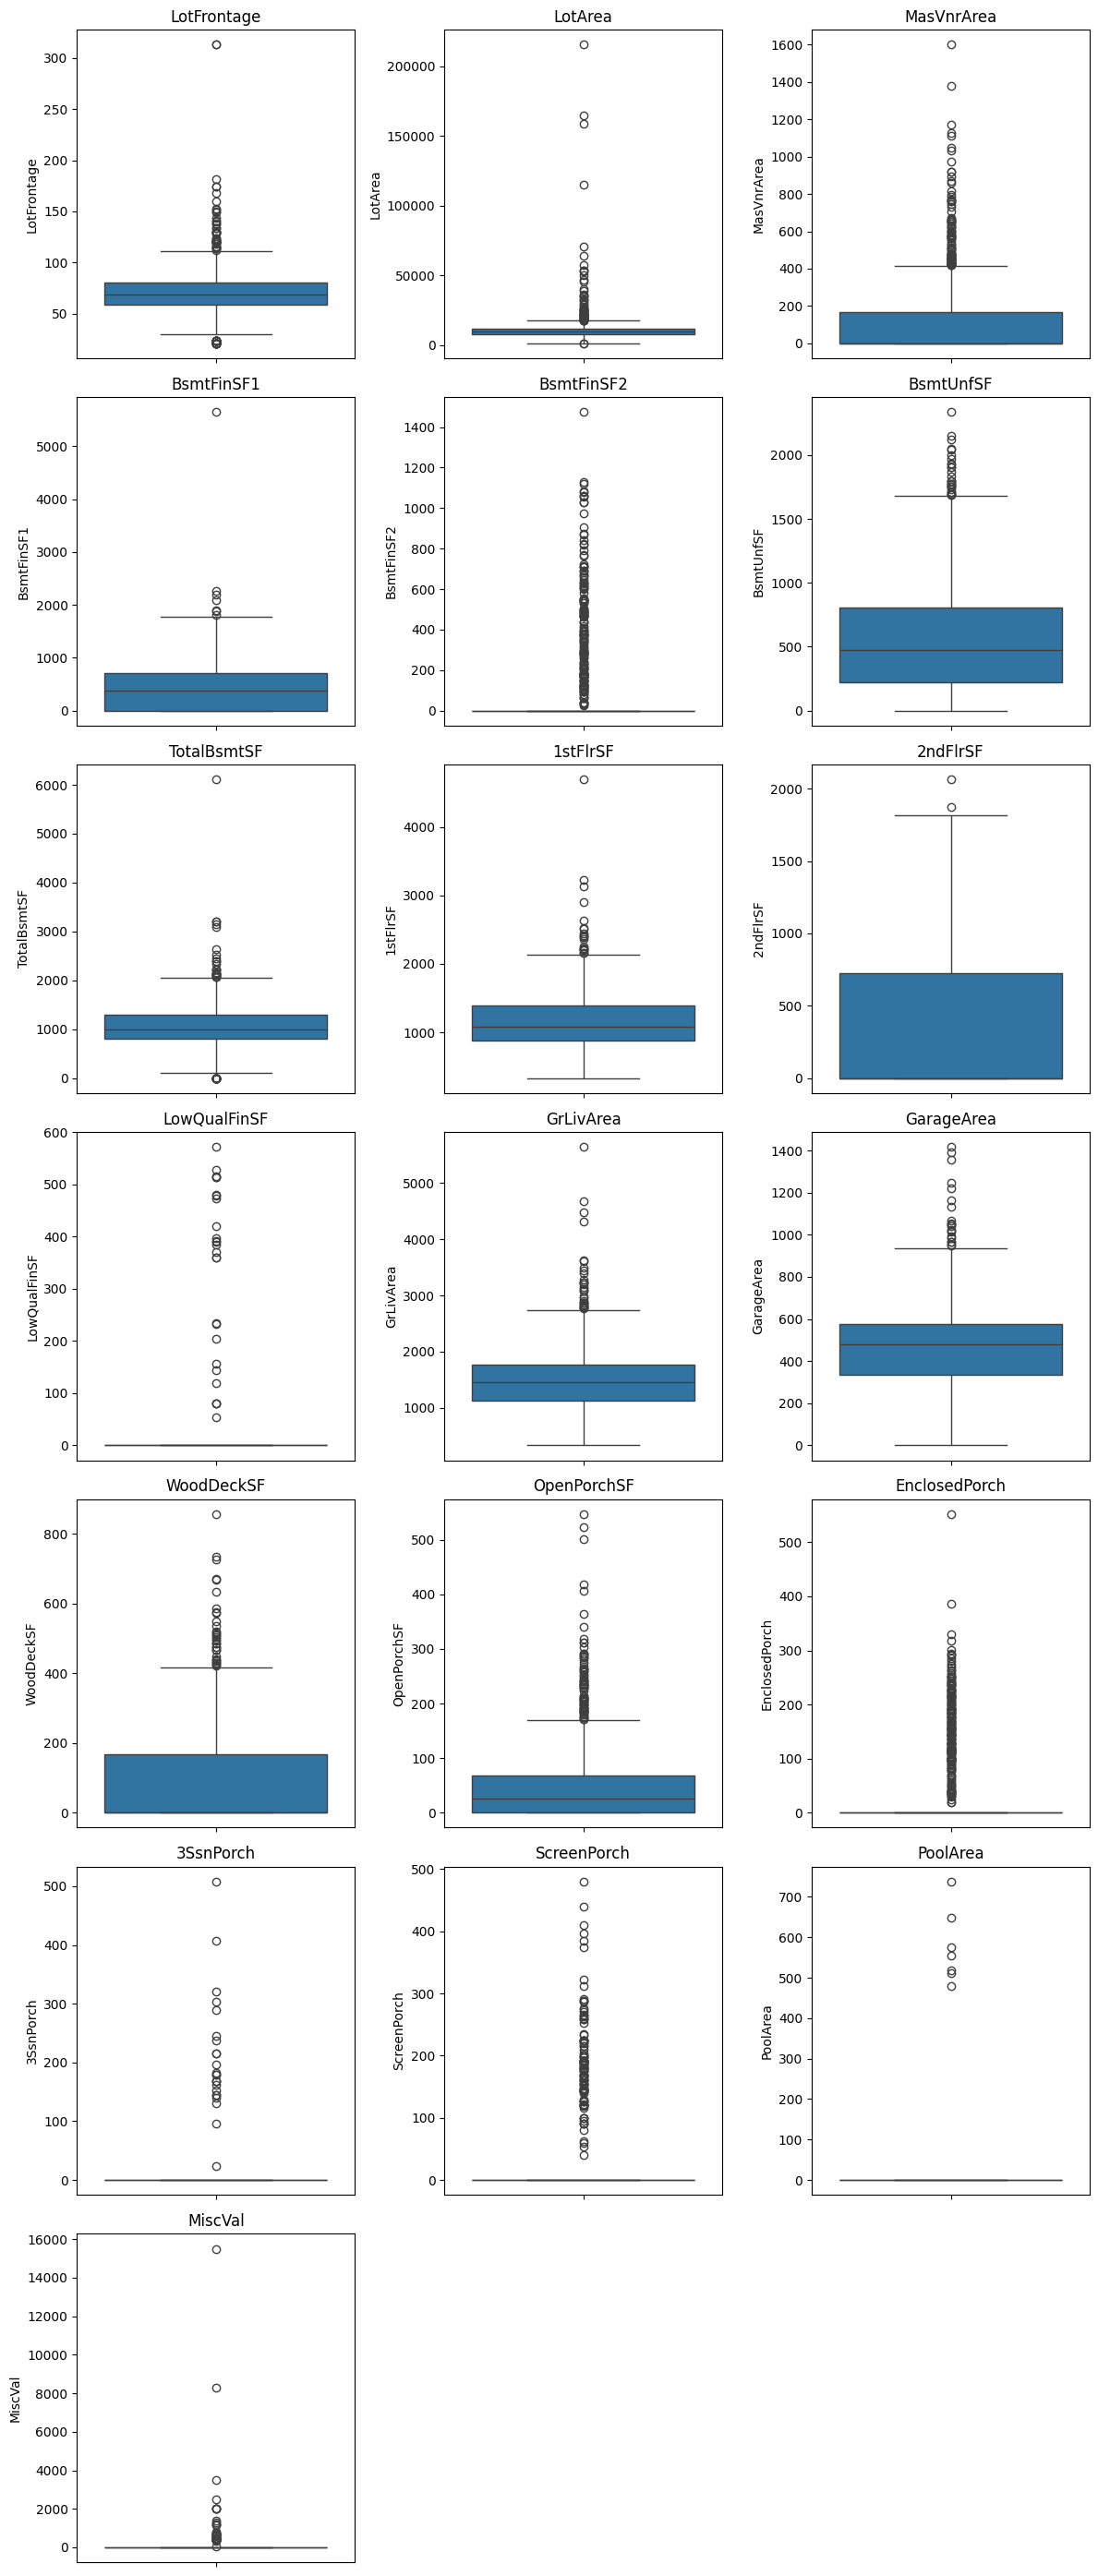

In [12]:
columnas = continuos 
n_cols = 3
n_rows = math.ceil(len(columnas) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 4))
axes = axes.flatten() 

for i, col in enumerate(columnas):
    sns.boxplot(data=df_tr, y=col, ax=axes[i])
    axes[i].set_title(f'{col}')
    axes[i].tick_params(axis='x', rotation=45)
    

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
    

# 4. Data Cleaning

## 4.1 Basement Inconsistencies

Before imputing, we noticed that basement-related columns have slightly inconsistent missing counts: most have 37 missing entries, while `BsmtExposure` and `BsmtFinType2` have 38. If a house truly has no basement, all basement columns should be missing simultaneously. The extra row in those two columns suggests a genuine data-entry gap rather than a structural absence.
The formal inspection and the drop are carried out in the bivariate section (5.3.1), where we can see them against SalePrice.

In [13]:

bsmt_cols = miss_table.index[miss_table.index.str.contains('Bsmt')]

def inconsistencies_bsmt(cols, particular_col, df):
   
    other_cols = [col for col in cols if col != particular_col]
    
    mask_particular_null = df[particular_col].isnull()
    mask_has_bsmt = df[other_cols].notna().any(axis=1)
    
    return df.loc[mask_particular_null & mask_has_bsmt, [particular_col] + other_cols]
        

In [14]:
display(inconsistencies_bsmt(bsmt_cols, 'BsmtExposure', df_tr))
display(inconsistencies_bsmt(bsmt_cols, 'BsmtFinType2', df_tr))

# Save idx for future import
idx_BsmtE = inconsistencies_bsmt(bsmt_cols, 'BsmtExposure', df_tr).index
idx_BsmtF2 = inconsistencies_bsmt(bsmt_cols, 'BsmtFinType2', df_tr).index

,BsmtExposure,BsmtFinType2,BsmtQual,BsmtCond,BsmtFinType1
948,NaN,Unf,Gd,TA,Unf


,BsmtFinType2,BsmtExposure,BsmtQual,BsmtCond,BsmtFinType1
332,NaN,No,Gd,TA,GLQ


## 4.2 Missing Value Imputation

### 4.2.1 NaN = None (Structural Absence)

According to the data dictionary, `NaN` in several columns means the feature simply **does not exist** for that property — it is not a missing value.

Affected columns:
- `PoolQC`, `MiscFeature`, `Alley`, `Fence`
- `MasVnrType`, `FireplaceQu`
- All garage and Bsmt-related columns with missing values `Garage*` and `Bsmt*`columns

These are filled with the string `'None'`.

In [15]:
cols_nan_is_none = [
    
    'PoolQC', 'MiscFeature',
    'Alley', 'Fence',
    'MasVnrType',
    'FireplaceQu',
    'GarageType',
    'GarageFinish',
    'GarageQual',
    'GarageCond',
    'BsmtFinType1',
    'BsmtFinType2',
    'BsmtExposure',
    'BsmtQual',
    'BsmtCond'
    
]

def imputation_none(df, cols_nan_is_none):
    for col in cols_nan_is_none:
        df[col] = df[col].fillna('None')
    

imputation_none(df_tr, cols_nan_is_none)

In [16]:
# Correcting the genuine with mode
has_bsmt = df_tr['BsmtQual'] != 'None'

df_tr.loc[idx_BsmtE, 'BsmtExposure'] = df_tr.loc[has_bsmt, 'BsmtExposure'].mode()[0]
df_tr.loc[idx_BsmtF2, 'BsmtFinType2'] = df_tr.loc[has_bsmt, 'BsmtFinType2'].mode()[0]

df_tr.loc[[idx_BsmtE[0],idx_BsmtF2[0]], ['BsmtExposure','BsmtFinType2', 'BsmtQual', 'BsmtCond', 'BsmtFinType1']]


,BsmtExposure,BsmtFinType2,BsmtQual,BsmtCond,BsmtFinType1
948,No,Unf,Gd,TA,Unf
332,No,Unf,Gd,TA,GLQ


### 4.2.2 Remaining Missing Values

In [17]:
missing_table(df_tr)

,Missing Count,Missing Percent
LotFrontage,259,17.7
GarageYrBlt,81,5.5
MasVnrArea,8,0.5
Electrical,1,0.1


#### Electrical

In [18]:

print(df_tr.Electrical.value_counts(dropna = False))

# The simple imputation should be by mode.
mode_electrical = df_tr.Electrical.mode()[0]
df_tr['Electrical'] = df_tr['Electrical'].fillna(mode_electrical)
print('-'*40)
print(df_tr.Electrical.value_counts(dropna = False))

Electrical
SBrkr    1334
FuseA      94
FuseF      27
FuseP       3
Mix         1
NaN         1
Name: count, dtype: int64
----------------------------------------
Electrical
SBrkr    1335
FuseA      94
FuseF      27
FuseP       3
Mix         1
Name: count, dtype: int64


#### MasVnrArea & MasVnrType

In [19]:
# MasVnrArea
print(df_tr.MasVnrArea.value_counts(dropna = False))

MasVnrArea
0.0      861
108.0      8
NaN        8
72.0       8
180.0      8
        ... 
426.0      1
96.0       1
438.0      1
194.0      1
119.0      1
Name: count, Length: 328, dtype: int64


With 872 `None` values in `MasVnrType`, we expect `MasVnrArea` to also have 872 zeros. Let's verify.

In [20]:
# Check if those Nan belongs with a None MasVnrType.
df_tr.loc[df_tr['MasVnrArea'].isna(), ['MasVnrArea', 'MasVnrType']]

,MasVnrArea,MasVnrType
234,NaN,None
529,NaN,None
650,NaN,None
936,NaN,None
973,NaN,None
977,NaN,None
1243,NaN,None
1278,NaN,None


All `NaN` rows in `MasVnrArea` correspond to `MasVnrType = None`, confirming structural absence. 

In [21]:
df_tr['MasVnrArea'] = df_tr['MasVnrArea'].fillna(0)
print(df_tr.MasVnrArea.value_counts(dropna = False))

MasVnrArea
0.0      869
108.0      8
72.0       8
180.0      8
120.0      7
        ... 
788.0      1
86.0       1
796.0      1
391.0      1
119.0      1
Name: count, Length: 327, dtype: int64


The count is lower than expected (869 instead of 872), indicating some rows have `MasVnrType = None` but a non-zero `MasVnrArea` — a data-entry inconsistency.

In [22]:
mask = (df_tr['MasVnrType'] == 'None') & (df_tr['MasVnrArea'] > 0)
show_incons = df_tr[mask][['MasVnrType', 'MasVnrArea']]
print(show_incons)

     MasVnrType  MasVnrArea
624        None       288.0
773        None         1.0
1230       None         1.0
1300       None       344.0
1334       None       312.0


Yes, we have an inconsistent measurement. The NaN in `MasVnrType` likely reflects a recording omission rather than a true absence of veneer.
I will trust `MasVnrArea` since specific numeric values suggest actual measurement. 

My action plan is to search by `MasVnrArea` value, If there is exactly 1 observation with the same `MasVnrArea` value, I will assign that `MasVnrType`. Otherwise, I will get the mode.

For MasVnrArea == 1, which is a very low measurement, I will fill those with 0.

In [23]:
# Get index to review 
idx_incons =show_incons.index

# Replace MasVnrArea == 1 with 0
df_tr['MasVnrArea'] = df_tr['MasVnrArea'].replace({1:0})

# Get the inconsistency values except 1
incons_val = show_incons[show_incons['MasVnrArea'] > 1]['MasVnrArea'].values

# Loop for search the mode 
for x in incons_val:
    mode = df_tr.loc[df_tr['MasVnrArea'] == x, 'MasVnrType'].mode()[0] # Get mode
    matches = df_tr.loc[df_tr['MasVnrArea'] == x, 'MasVnrType'] # Get count of match 
    count = len(matches)
    # Apply changes to the original df
    df_tr.loc[
    (df_tr['MasVnrArea'] == x) & (df_tr['MasVnrType'] == 'None'), 'MasVnrType'
    ] = mode
    print(f'Area {x} | matches: {count} | mode: {mode}')

Area 288.0 | matches: 4 | mode: BrkFace
Area 344.0 | matches: 2 | mode: BrkFace
Area 312.0 | matches: 3 | mode: BrkFace


In [24]:
df_tr.loc[idx_incons, ['MasVnrType', 'MasVnrArea']]

,MasVnrType,MasVnrArea
624,BrkFace,288.0
773,None,0.0
1230,None,0.0
1300,BrkFace,344.0
1334,BrkFace,312.0


#### LotFrontage

In [25]:
# LotFrontage
print(df_tr.LotFrontage.value_counts(dropna = False))

LotFrontage
NaN      259
60.0     143
70.0      70
80.0      69
50.0      57
        ... 
182.0      1
160.0      1
152.0      1
153.0      1
46.0       1
Name: count, Length: 111, dtype: int64


`LotFrontage` is a continuous variable with approximately 17.7% missing data. To maintain accuracy, we impute these values using related spatial features; `Neighborhood` is the most logical choice as lot sizes are heavily dictated by local zoning and development patterns.  

In [26]:
df_tr.groupby('Neighborhood')['LotFrontage'].agg(Missing_values_by_neigh_for_LotFrontage = 
                                                 lambda x: x.isnull().sum()).sort_values(ascending = False, 
                                                 by = 'Missing_values_by_neigh_for_LotFrontage')

,Missing_values_by_neigh_for_LotFrontage
Neighborhood,
NAmes,39
Gilbert,30
NWAmes,28
Sawyer,26
CollgCr,24
ClearCr,15
Mitchel,13
Crawfor,10
SawyerW,9


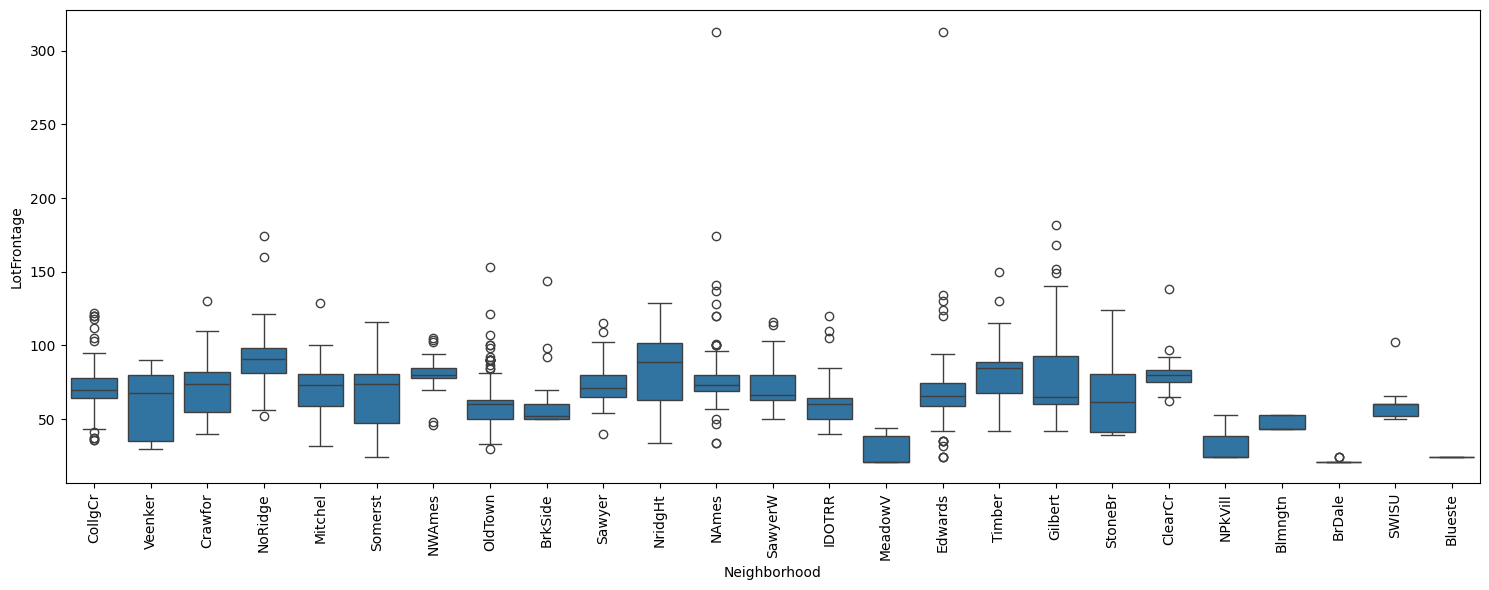

In [27]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=df_tr, y = 'LotFrontage', x = 'Neighborhood')
plt.xticks(rotation='vertical')
plt.tight_layout()
plt.show()

In [28]:
before_func = df_tr['LotFrontage'].copy()

In [29]:
np.random.seed(SEED)

def impute_lot_frontage_sampled(group):
    # Get the non-null values to sample from
    valid_values = group.dropna()
    
    # If the neighborhood is entirely NaNs (rare but possible), return as is or fill globally
    if valid_values.empty:
        return group
        
    n_missing = group.isnull().sum()
    if n_missing == 0: 
        return group
        
    group = group.copy()
    mask = group.isna()
    
    # Sample randomly from the neighborhood's existing valid values
    group.loc[mask] = np.random.choice(valid_values, size=n_missing, replace=True)
    
    return group
               
df_tr['LotFrontage'] = df_tr.groupby('Neighborhood')['LotFrontage'].transform(impute_lot_frontage_sampled)

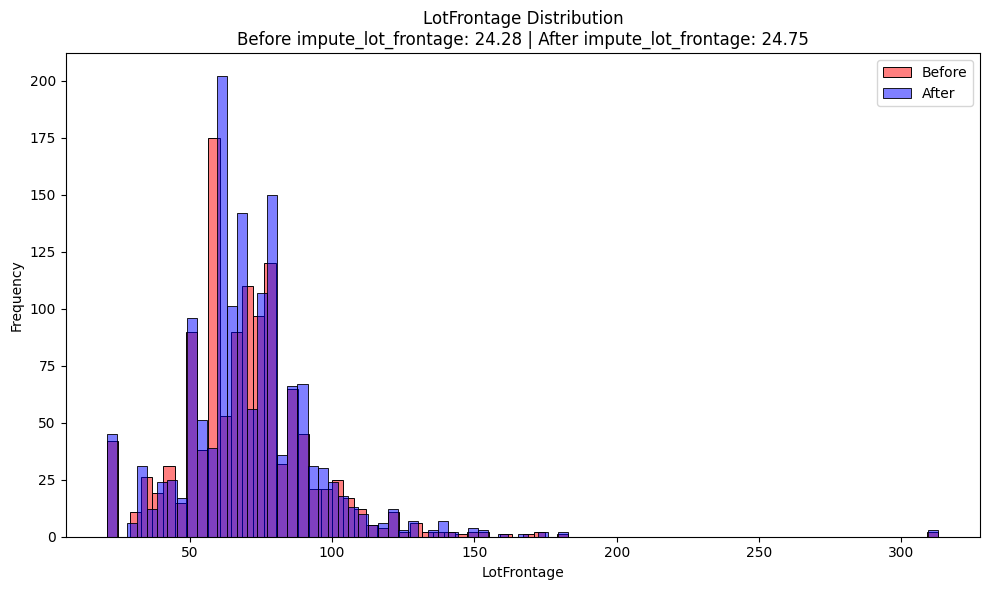

In [30]:
plt.figure(figsize=(10,6))

# Before
sns.histplot(before_func, color="red", alpha=0.5, label="Before")

# After
sns.histplot(df_tr['LotFrontage'], color="blue", alpha=0.5, label="After")

plt.title(
    f"LotFrontage Distribution\n"
    f"Before impute_lot_frontage: {before_func.std():.2f} | After impute_lot_frontage: {df_tr['LotFrontage'].std():.2f}"
)

# Leyenda y ejes
plt.xlabel("LotFrontage")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()



**LotFrontage Imputation Analysis - Key Findings:**


1. Neighborhood Variability: Medians range from 50–100 depending on the area, confirming that grouping by Neighborhood is significantly more accurate than using a global median.
2. Low-Density Zones: Areas like MeadowV or BrDale drop to ~30. Random sampling prevents biasing these small clusters.
3. Outlier Preservation: Large lots (>300) in NAmes and Edwards are preserved. Random sampling maintains these extremes without artificially inflating central statistics.

We implemented Hot-Deck imputation (Random Sampling). Unlike simple median filling, this method preserves the original standard deviation (~24.28) and prevents artificial spikes in the distribution, ensuring data integrity for the machine learning model.


#### GarageYrBlt

In [31]:
# GarageYrBlt
garage = df_tr.columns[df_tr.columns.str.contains('garage', case=False)]
for col in garage:
    print(df_tr.loc[df_tr['GarageYrBlt'].isna(), col].value_counts(dropna=False, sort=False))

GarageType
None    81
Name: count, dtype: int64
GarageYrBlt
NaN    81
Name: count, dtype: int64
GarageFinish
None    81
Name: count, dtype: int64
GarageCars
0    81
Name: count, dtype: int64
GarageArea
0    81
Name: count, dtype: int64
GarageQual
None    81
Name: count, dtype: int64
GarageCond
None    81
Name: count, dtype: int64


All NaN values in GarageYrBlt align with GarageType = None and GarageArea = 0, confirming structural absence (no garage). These will be handled during feature engineering."

# 5. Exploratory Data Analysis

In [32]:
data = df_tr # alias for convenience

## 5.1 Target Variable: SalePrice

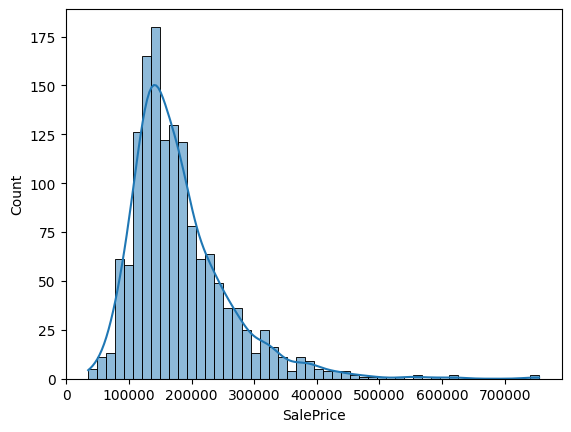

In [33]:
sns.histplot(data=data, x = 'SalePrice', bins = 50, kde = True)
plt.show()

In [34]:
df_tr['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

<Axes: ylabel='SalePrice'>

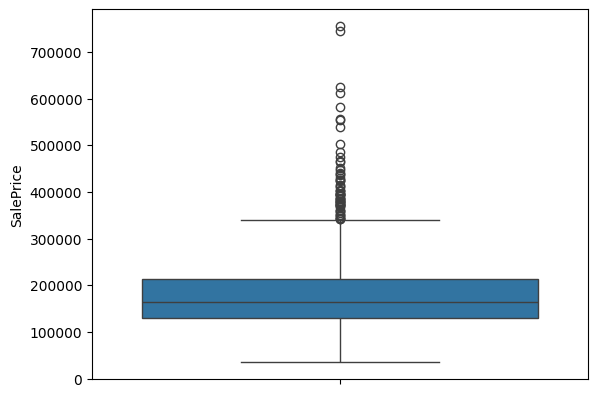

In [35]:
sns.boxplot(data=data, y= 'SalePrice')

The `SalePrice` distribution shows a right skew. Tree-based models handle skewed targets natively, but applying log1p can still improve the model's optimization on RMSLE-based metrics — which is the competition's evaluation metric. We'll apply it during training.

## 5.2 Univariate Analysis

In [36]:
def plot_num_block(cols, title, n_cols=5, plot_type = "count", target = None):

    if not cols:
        return

    n_rows = math.ceil(len(cols) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.01)
    axes = axes.flatten()

    for i, col in enumerate(cols):
        if plot_type == 'countplot':
        
            order = df_tr[col].value_counts().index.tolist()
            sns.countplot(data=data, x = col, y=target, order=order, stat="percent", ax=axes[i])

        elif plot_type == 'scatterplot' and target is not None:

            sns.scatterplot(data=data, x = col, y = target, ax=axes[i])
        
        elif plot_type == 'boxplot' and target is not None:
            
            order = df_tr.groupby(col)['SalePrice'].median().sort_values().index
            sns.boxplot(data=data, x = col, y=target, order=order, ax=axes[i])
            
        elif plot_type == 'histplot':
            
            sns.histplot(data=data, x=col, kde= True, ax=axes[i])

        axes[i].set_title(col, fontsize=10)
        axes[i].tick_params(axis='x', rotation=45)
        plt.setp(axes[i].get_xticklabels(), ha='right', rotation_mode='anchor')

    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

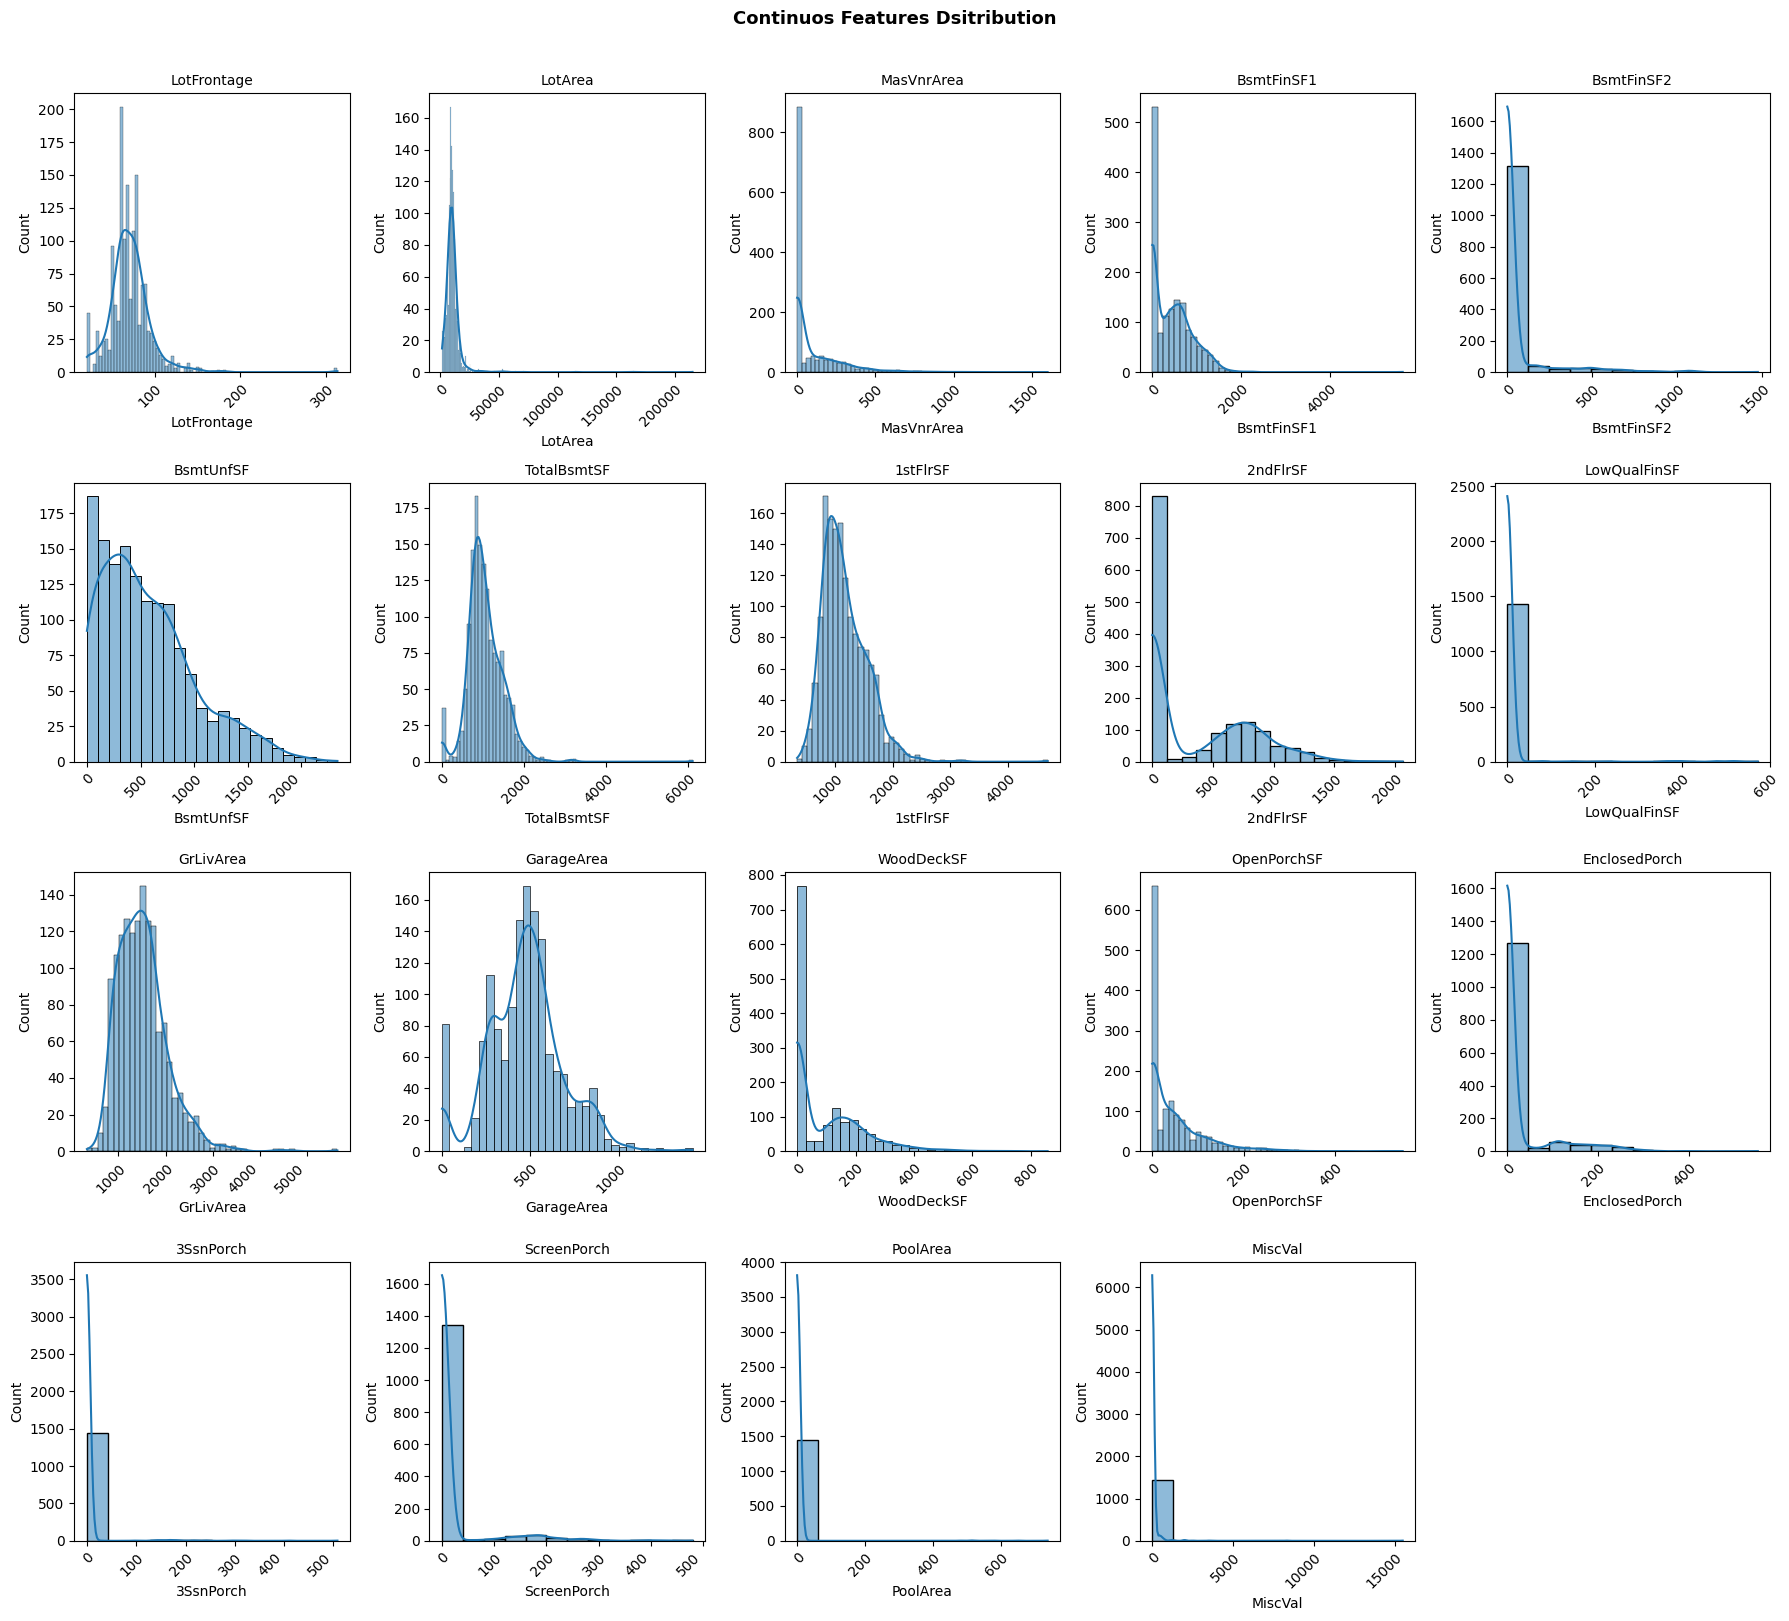

In [37]:
plot_num_block(continuos, 
               'Continuos Features Dsitribution', 
               n_cols=5, 
               plot_type = "histplot", 
               target = None)

I identified 3 distribution patterns across continuous features:

1. **Zero-inflated** (`MasVnrArea, BsmtFinSF2, 2ndFlrSF, WoodDeckSF, OpenPorchSF, EnclosedPorch, ScreenPorch`): The large spike at zero indicates most houses lack these features. This is meaningful information, not noise. In feature engineering, binary indicators will be created to separate presence from magnitude.

2. **Right skew** (`LotArea, LotFrontage, BsmtFinSF1, GrLivArea, 1stFlrSF`): Expected for area-based features.

3. **Temporal** (`YearBuilt, GarageYrBlt, YearRemodAdd`): Construction activity increases toward recent years. Transforming to age will be explored in feature engineering.


In [38]:
# Check for dominant categories in nominal/ordinal and discrete features
dominant_cat = [col for col in nominal_cols + ordinal_cols
                  if df_tr[col].value_counts(normalize=True).iloc[0] > 0.70]
# If the most common category in a nominal/ordinal column accounts for more than 70% of the data, it's considered dominant and MAY be excluded from modeling or apply feature engineering.

print(f'Dominant nominal/ordinal (excluded): {dominant_cat}')

Dominant nominal/ordinal (excluded): ['MSZoning', 'Street', 'Alley', 'LandContour', 'Utilities', 'LotConfig', 'Condition1', 'Condition2', 'BldgType', 'RoofStyle', 'RoofMatl', 'Heating', 'CentralAir', 'Electrical', 'MiscFeature', 'SaleType', 'SaleCondition', 'ExterCond', 'BsmtCond', 'BsmtFinType2', 'GarageQual', 'GarageCond', 'PavedDrive', 'Fence', 'PoolQC', 'Functional', 'LandSlope']


The meaningful signal comes from how each category relates to `SalePrice`, so we move directly to bivariate analysis against the target. Features with a single dominant category (>70% of values) will be flagged as low-variance candidates for removal during feature engineering.

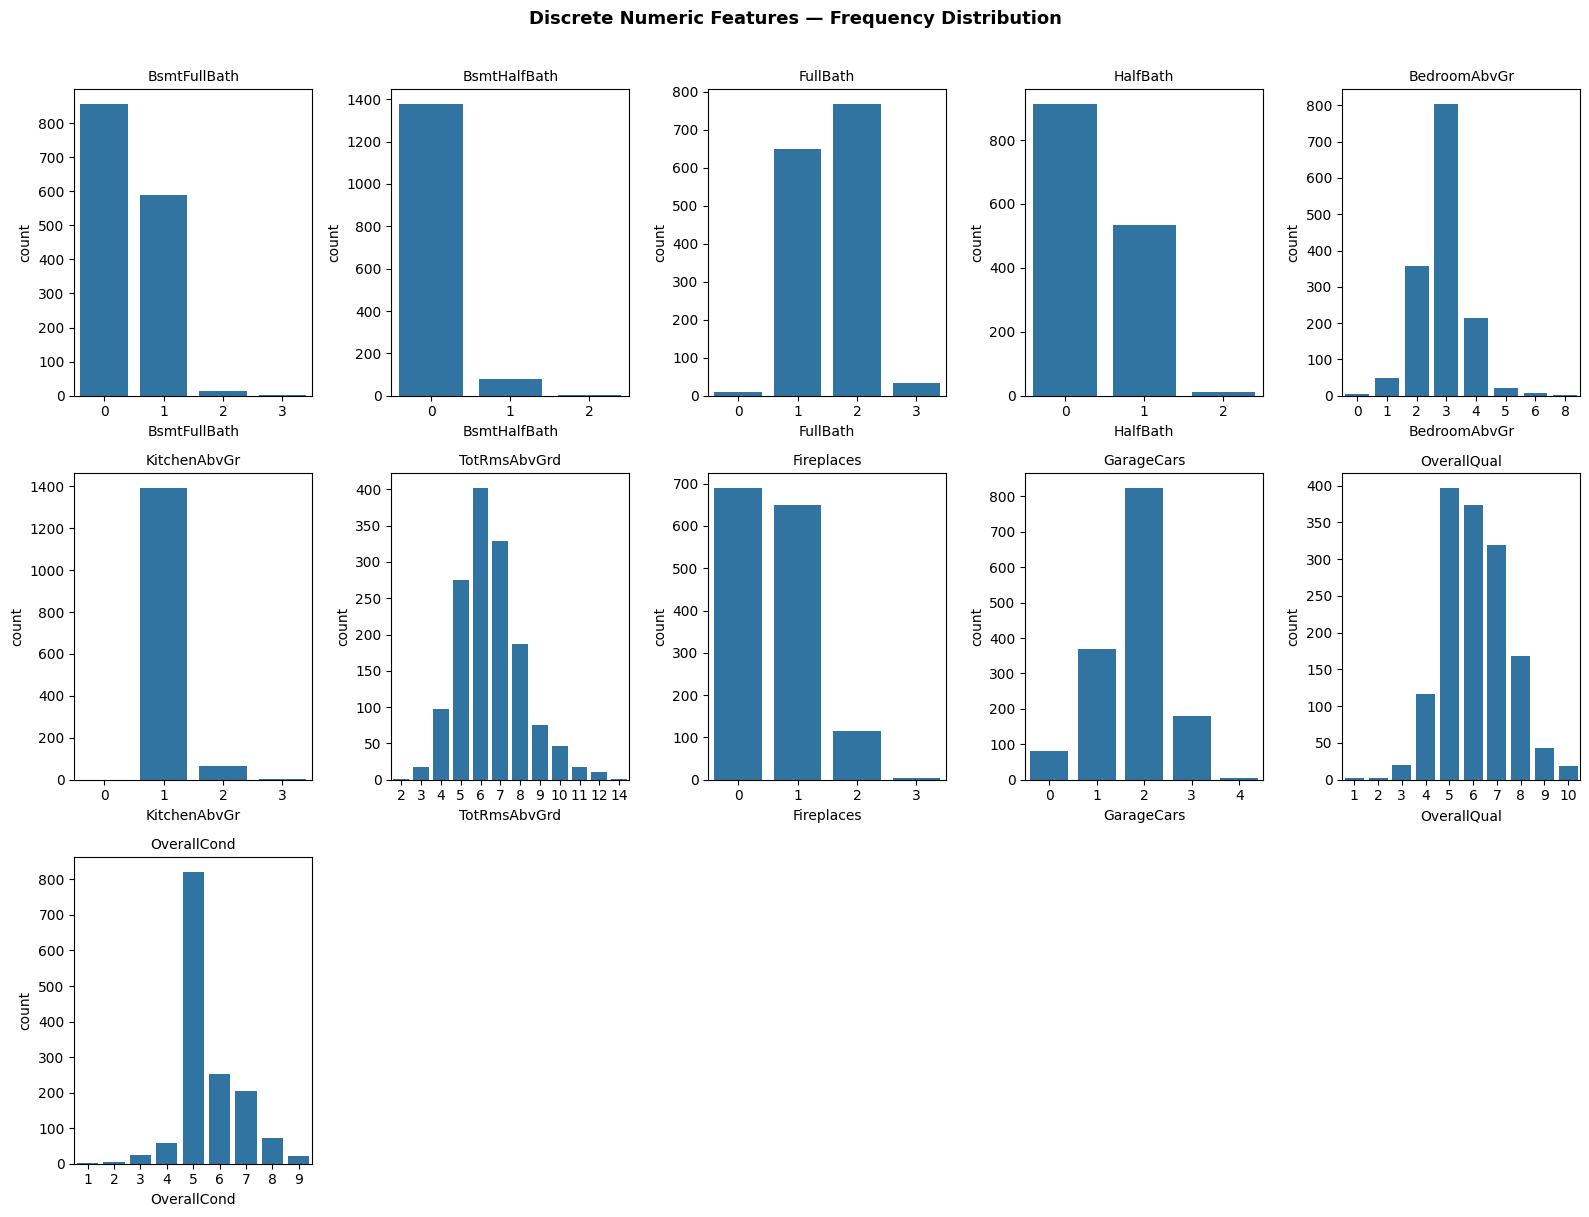

In [39]:
disc_plot = discrete
n_cols_d = 5
n_rows_d = math.ceil(len(disc_plot) / n_cols_d)
fig, axes = plt.subplots(n_rows_d, n_cols_d, figsize=(16, n_rows_d * 4))
fig.suptitle('Discrete Numeric Features — Frequency Distribution', fontsize=13, fontweight='bold', y=1.01)
axes = axes.flatten()
for i, col in enumerate(disc_plot):
      order = sorted(df_tr[col].dropna().unique())
      counts = df_tr[col].value_counts().reset_index()
      counts.columns = [col, 'count']
      sns.barplot(data=counts, x=col, y='count', order=order, ax=axes[i])
      axes[i].set_title(col, fontsize=10)

for j in range(i + 1, len(axes)):
          
          fig.delaxes(axes[j])


plt.tight_layout()
plt.show()

In [40]:
def plot_cat_block(cols, title, order_fn, n_cols=5, plot_type = "count", target = None):
      # Exclude dominant categories from the plot to focus on more informative features
      cols = [c for c in cols if c not in dominant_cat]
      if not cols:
          return # If all columns are dominant, skip plotting
      
      n_rows = math.ceil(len(cols) / n_cols)

      fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
      fig.suptitle(title, fontsize=13, fontweight='bold', y=1.01)
      axes = axes.flatten()
          
      for i, col in enumerate(cols):
          # Get the order of categories based on the provided order function (e.g., frequency, target mean)
          order = order_fn(col)
          order = [v for v in order if v in df_tr[col].values] # Ensure order only includes present categories
            
          if plot_type == "count":
              sns.countplot(data=data, x=col, ax=axes[i], order=order)
          elif plot_type == "boxplot" and target is not None:
              sns.boxplot(data=data, x=col, y = target, ax=axes[i], order=order)
              
          axes[i].set_title(col, fontsize=10)
          axes[i].tick_params(axis='x', rotation=45)
          plt.setp(axes[i].get_xticklabels(), ha='right', rotation_mode='anchor')
          
      for j in range(i + 1, len(axes)):
          
          fig.delaxes(axes[j])
      plt.tight_layout()
      plt.show()

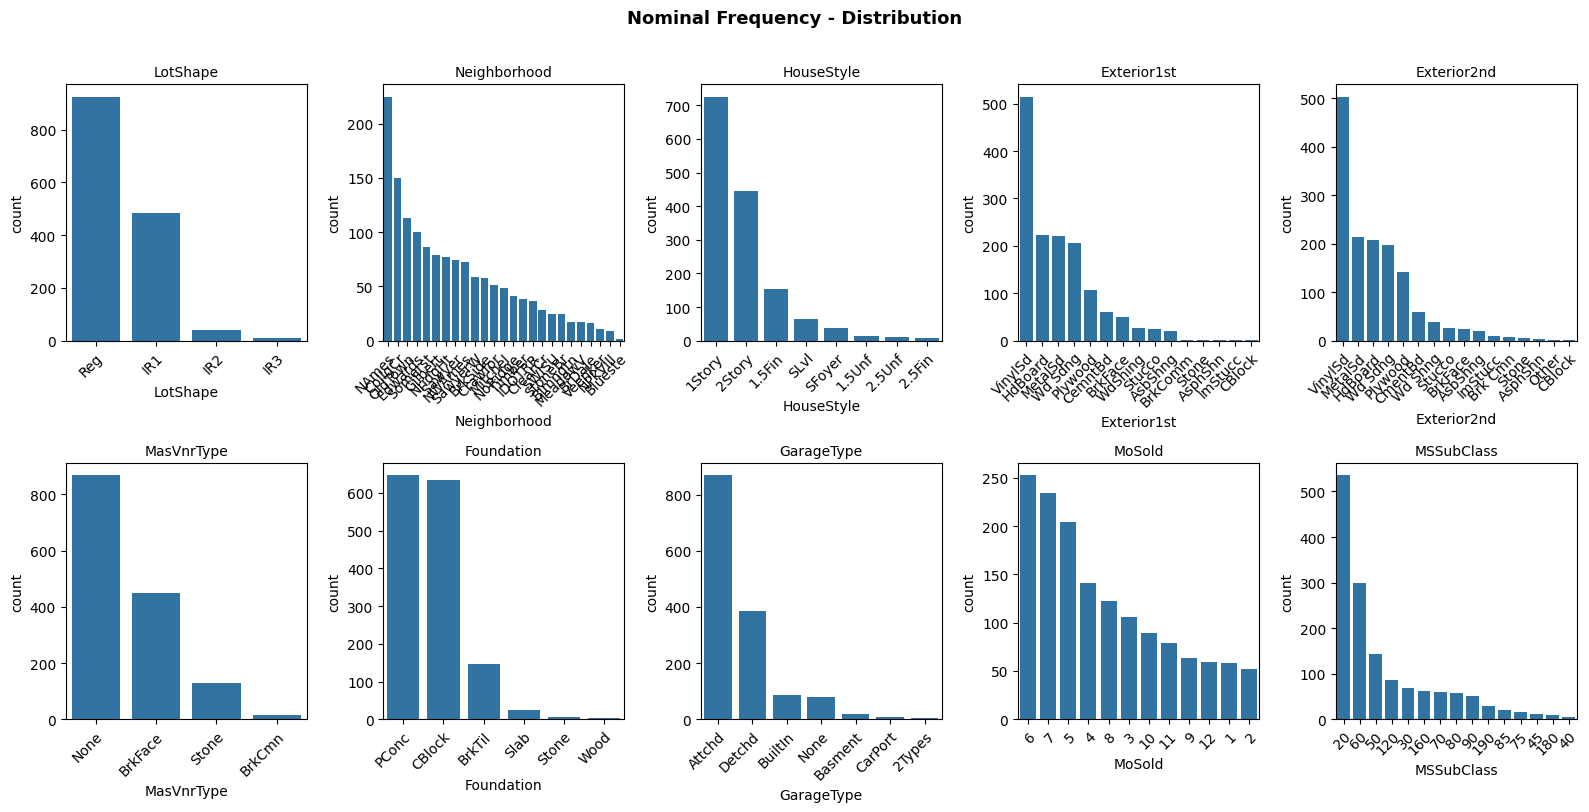

In [41]:
plot_cat_block(
      nominal_cols,
      'Nominal Frequency - Distribution',
      order_fn=lambda col: df_tr[col].value_counts().index.tolist()
  )

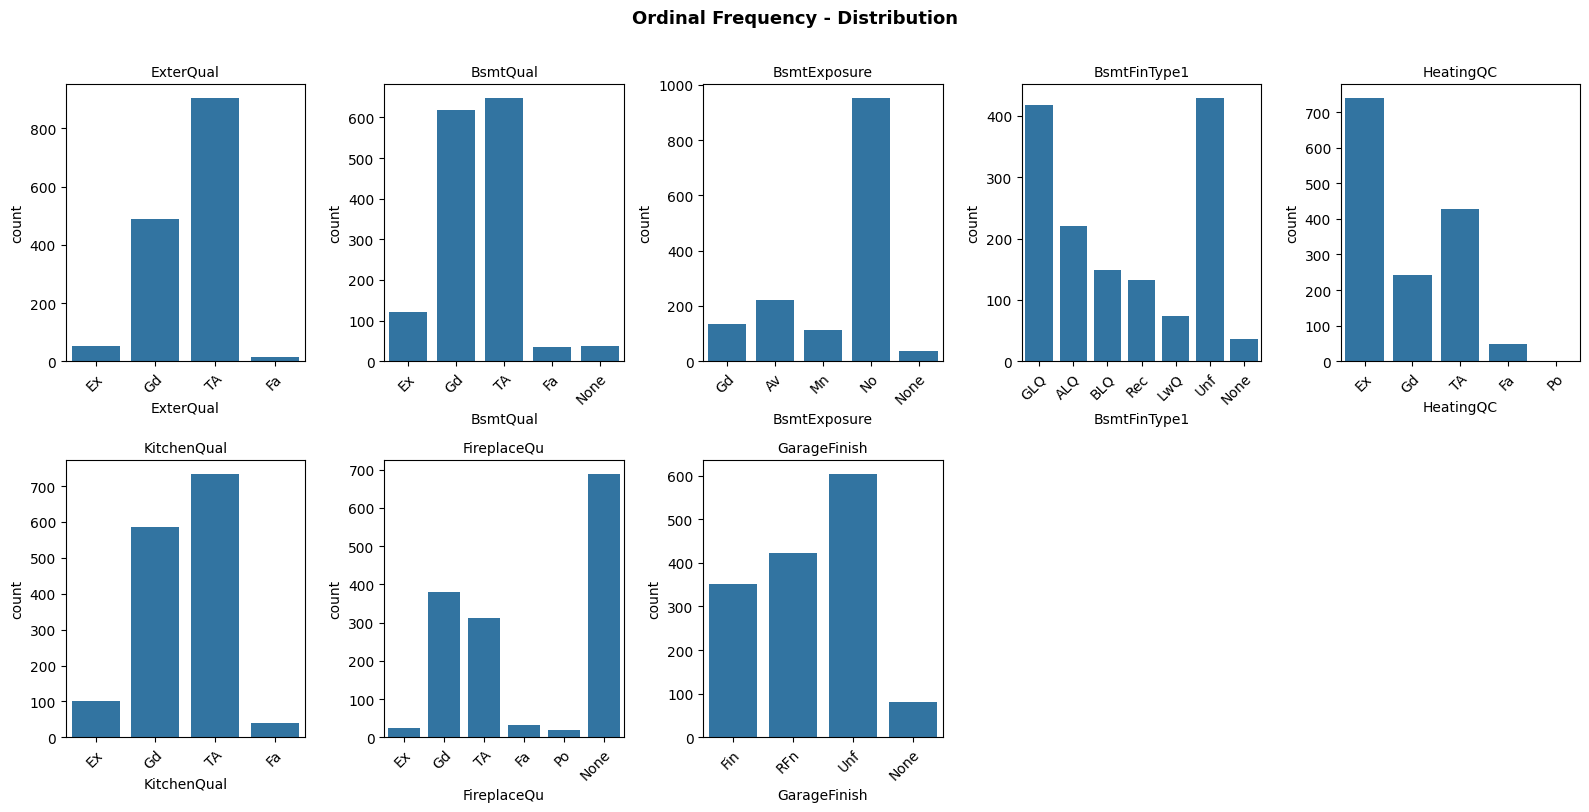

In [42]:
plot_cat_block(
      ordinal_cols,
      'Ordinal Frequency - Distribution',
      order_fn= lambda col: ordinal_order.get(col, df_tr[col].value_counts().index.tolist())
  )

The bar charts reveal the frequency distribution of each categorical feature. Some features show high cardinality or heavily imbalanced categories these are noted here but no action is taken yet. Grouping and encoding decisions will be made in the bivariate analysis, where category behavior against `SalePrice` determines the strategy.

## 5.3 Bivariate Analysis

### 5.3.1 Numeric Bivariate Analysis

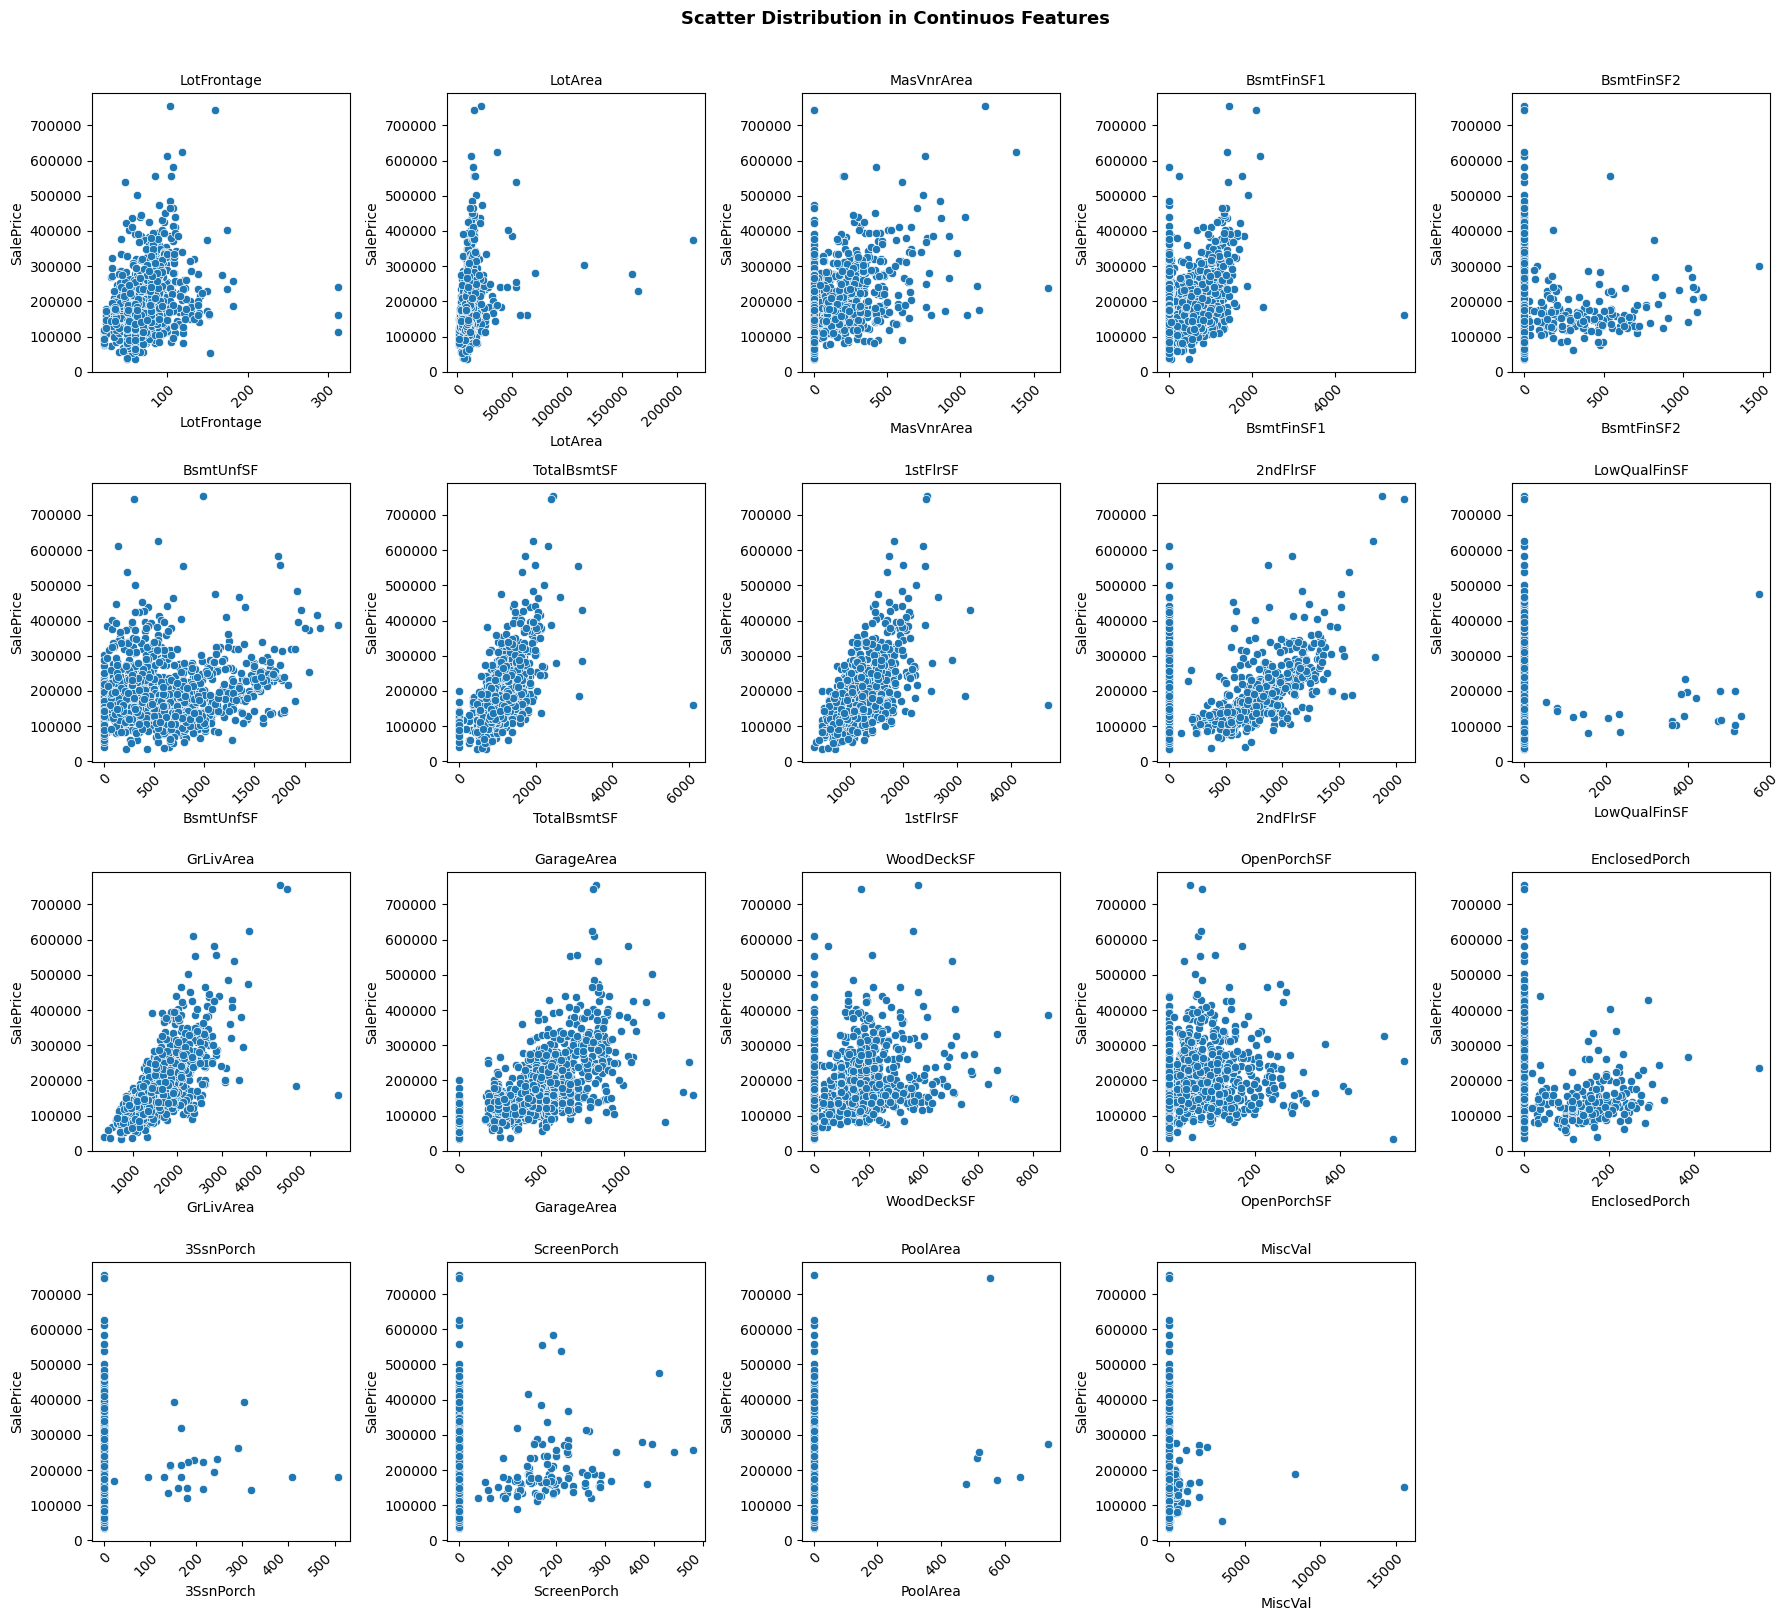

In [43]:
plot_num_block(continuos, 
               'Scatter Distribution in Continuos Features', 
               n_cols=5, 
               plot_type = "scatterplot", 
               target = 'SalePrice')

Key observations across continuous features:

1. Zero-inflated features: Several variables show a heavy concentration at zero, reflecting the absence of a feature rather than an actual measurement. These fall into three groups:

- Drop: Features where non-zero values show no meaningful trend with SalePrice (`LowQualFinSF, PoolArea, MiscVal, BsmtFinSF2, 3SsnPorch`).
- Combine: Porch-related features (`WoodDeckSF, OpenPorchSF, EnclosedPorch, ScreenPorch`) will be merged into a single TotalPorchSF feature to reduce sparsity while preserving the overall signal.
- Retain: Features where non-zero values do show a positive trend (`MasVnrArea, 2ndFlrSF`) are kept as-is.


2. Strong association with SalePrice: `GrLivArea, 1stFlrSF, TotalBsmtSF`, and `BsmtFinSF1` show the clearest positive correlation with the target. These are expected to rank high in feature importance after training.
3. Remaining features: Show weaker or less structured associations. They are retained for now and will be evaluated by the model during training.

  ---
  Flagged outliers:

Following De Cock’s (2011) recommendation, rows that simultaneously meet an extreme area measure and an abnormally low SalePrice are removed from the training set. They are not removed from the test set (Kaggle evaluates on all rows).

* GrLivArea > 4000 & SalePrice < 300000: typically 2 rows (houses with huge living area sold cheaply → very likely recording errors or special sales).

* LotArea > 100000 & SalePrice < 300000:


In [44]:
# Flagged Outliers
flagged = {}
flagged['GrLivArea'] = df_tr.loc[(df_tr['GrLivArea'] > 4000) & (df_tr['SalePrice']< 300000)].index
flagged['LotArea'] = df_tr.loc[(df_tr['LotArea'] > 100000) & (df_tr['SalePrice']< 300000)].index

flagged

{'GrLivArea': Index([523, 1298], dtype='int64'),
 'LotArea': Index([249, 335], dtype='int64')}

### 5.3.2 Categoric Bivariate Analysis

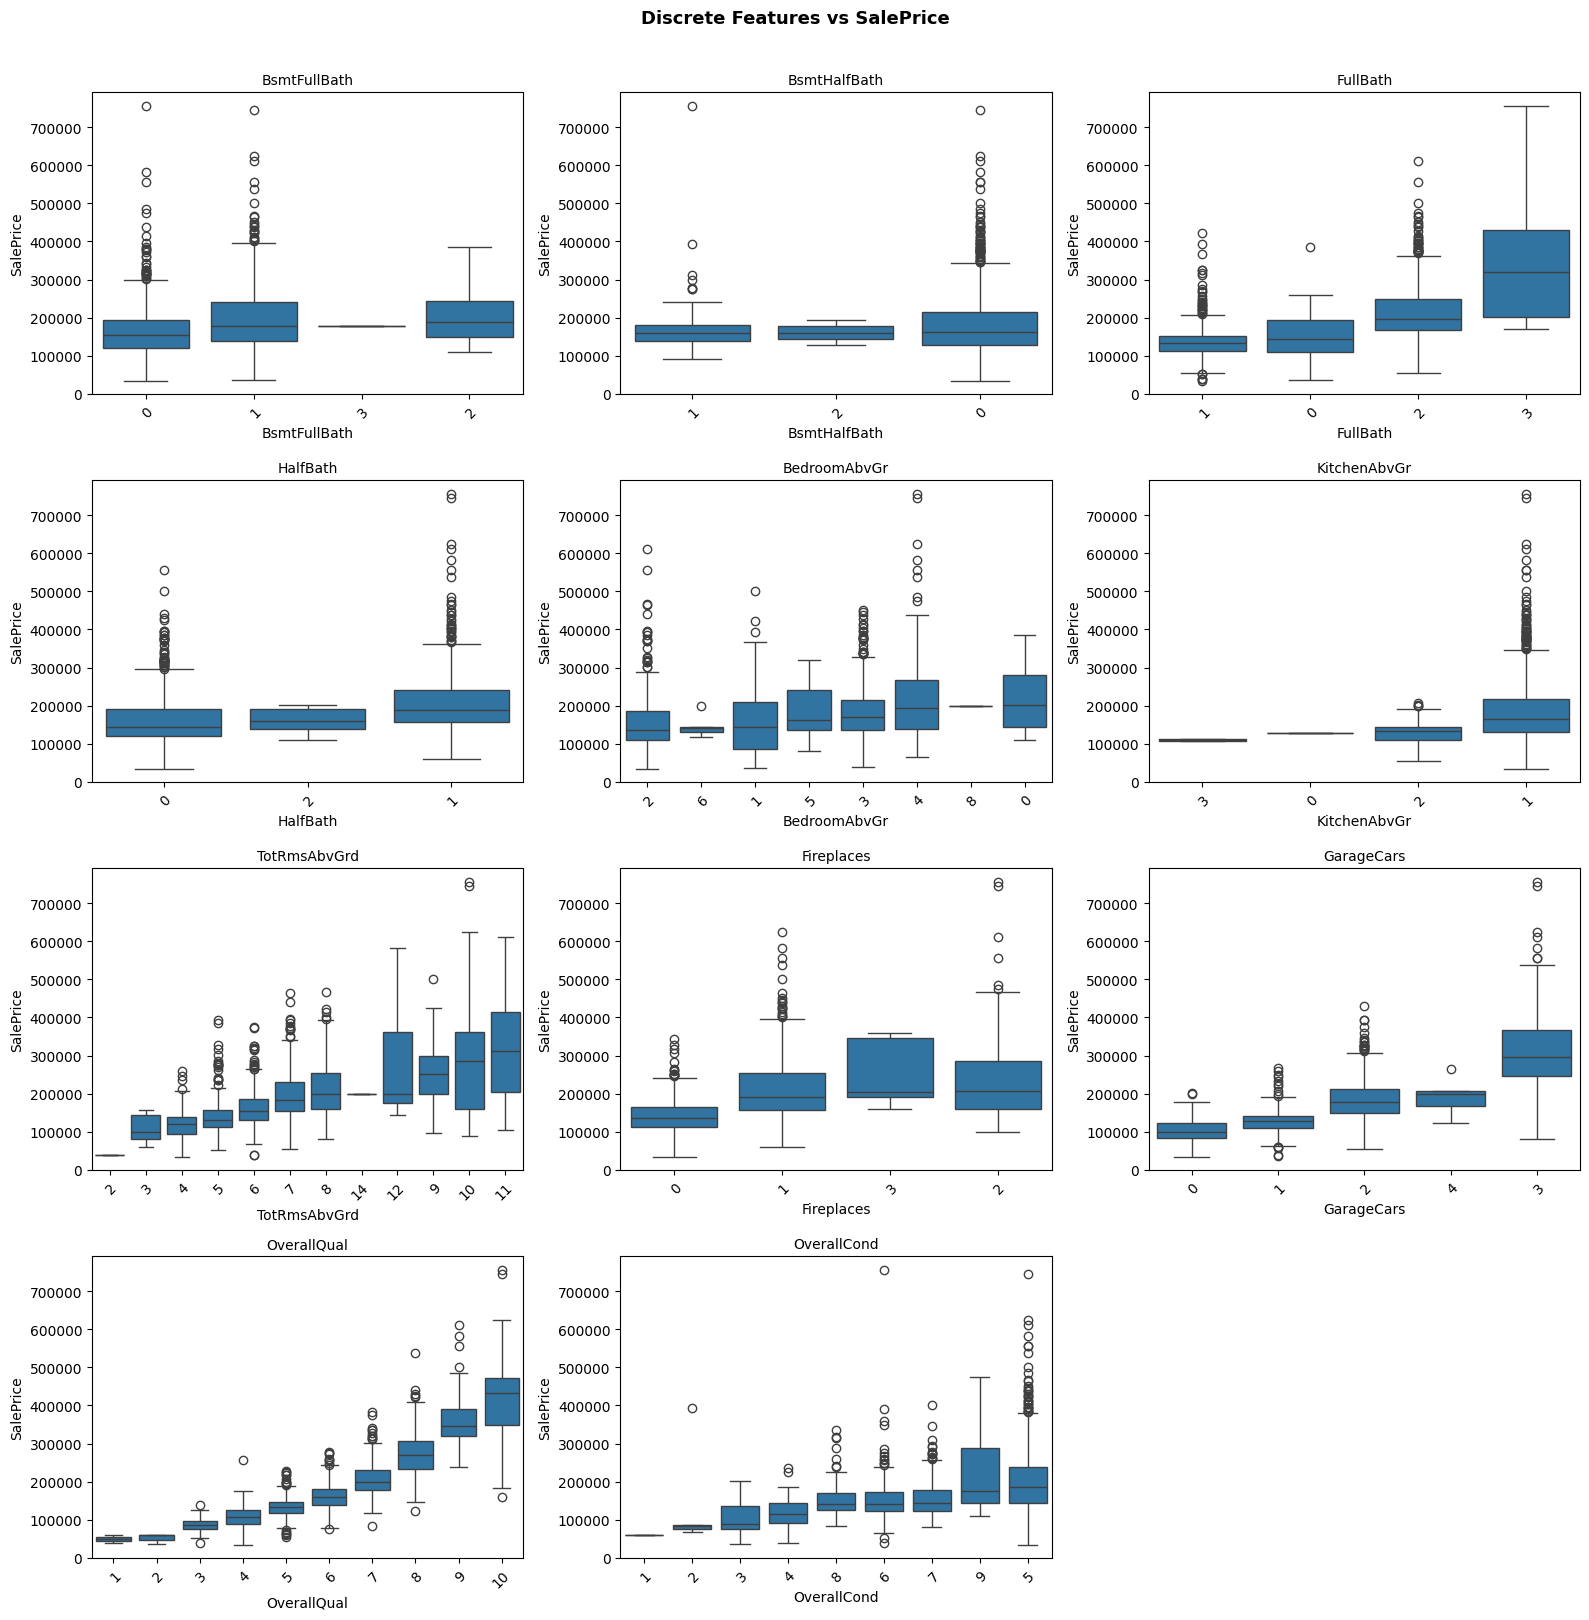

In [45]:
plot_cat_block(discrete, 'Discrete Features vs SalePrice', 
               order_fn = lambda col: df_tr.groupby(col)['SalePrice'].median().sort_values().index, 
               n_cols=3, 
               plot_type = "boxplot", 
               target = 'SalePrice')

Key observations across Discrete features:

1. `FullBath` plays a meaningful role in determining price, while the remaining bath variables show little variation in SalePrice. Creating a weighted total bath count would be more informative -`TotalBath = FullBath + BsmtFullBath + 0.5*(HalfBath + BsmtHalfBath)`, then drop original features.

2. The `BedroomAbvGr's` boxplots are largely aligned, which confirms a weak individual signal. The extreme values (0, 1, 6, 8) may need to be grouped, as their boxplots are unreliable due to small sample sizes. However, this remains a contingency plan; for the time being, I will retain the original categories and monitor their behavior.

3. Homes with `fireplaces` show a clearly higher median SalePrice. A binary grouping (has/doesn't have) is sufficient and clean.

4. The relationship between **garage** capacity and price is strong and consistent across categories. Leaving it as-is is the right decision.

5. `OverallQual` is by far the strongest predictor in this group. The boxplots show a clean upward trend from quality 1 to 10. Values 1 and 2 share similar distributions and very few samples.

6. We could keep the original `OverallCond` data and monitor its behavior. An auxiliary complement would be to create a new column, overallC_is5 (True/False), to help the model split the data more efficiently.

7. `KitchenAbvGr` is particular, the majority of properties have only one kitchen, rarely two and extremely abnormal three and more super abnormal 0. So the best way is transform to a binary feature.


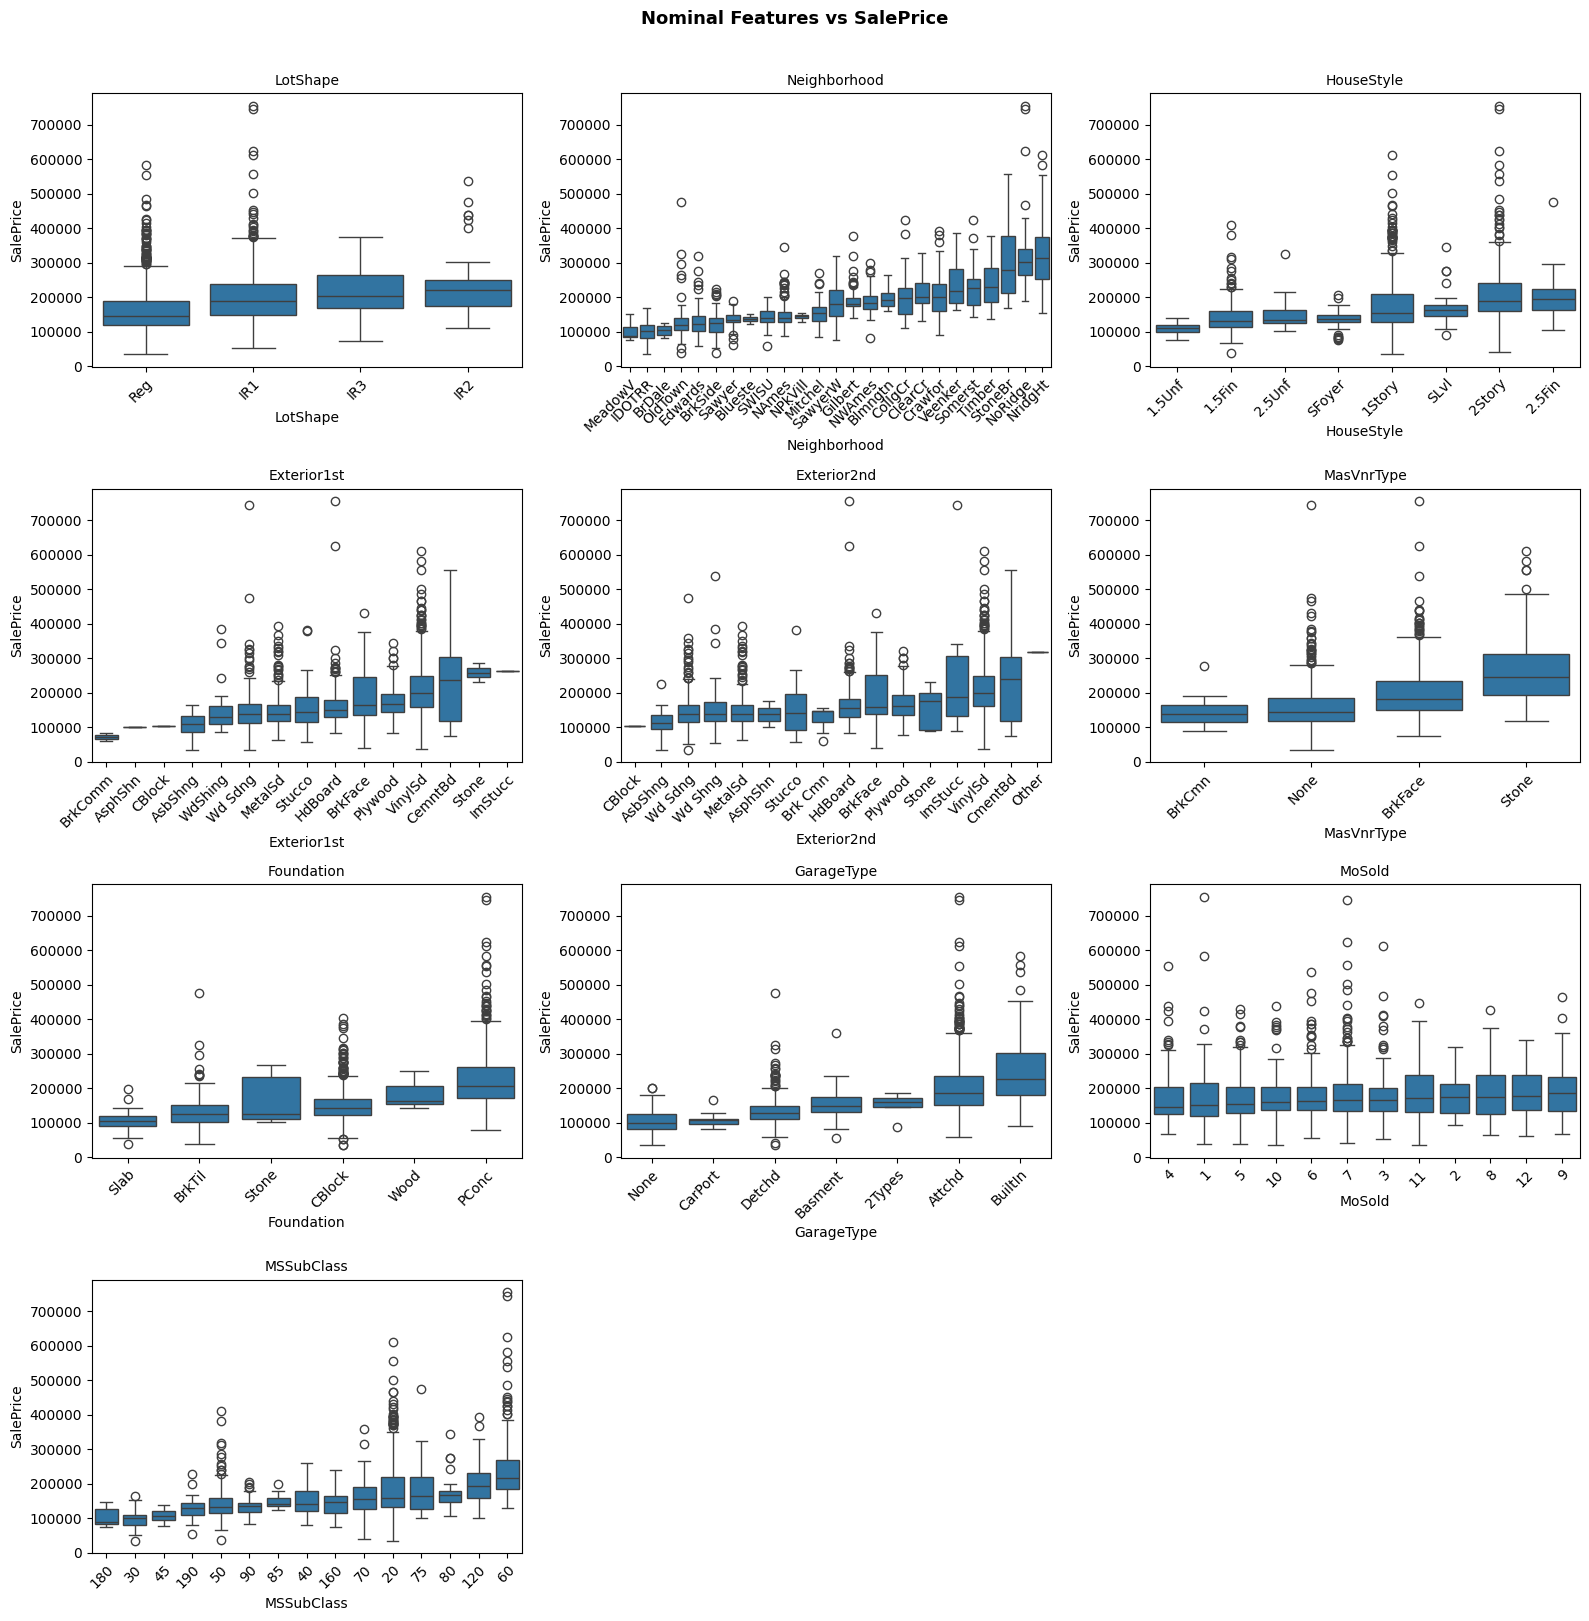

In [46]:
plot_cat_block(nominal_cols, 'Nominal Features vs SalePrice', 
               order_fn = lambda col: df_tr.groupby(col)['SalePrice'].median().sort_values().index, 
               n_cols=3, 
               plot_type = "boxplot", 
               target = 'SalePrice')

By difference we have here some features with most cardinality, let's start with them by the best to worst feature variance then with each other.

- `Neighborhood`: Shows the clearest variance pattern with SalePrice. However, its high cardinality (~25 values) and strong imbalance make LabelEncoder suboptimal — assigning alphabetical integers forces the tree to search for a meaningless order.
The correct alternative is Out‑Of‑Fold target encoding with Bayesian smoothing: replace each neighborhood by the mean of log(SalePrice) calculated without including the row being predicted (avoids leakage), and regularize rare categories toward the global mean (avoids unstable estimates). Smoothing removes the need to group rare categories into “Others.”
- `MSSubClass`: Same reasoning as Neighborhood. High cardinality + strong signal → Out‑Of‑Fold target encoding.
- `Exterior1st and Exterior2nd`: Both have a similar behavior in both graphics (boxplot and countplot), many houses share the same primary and secondary material. The idea here is to create a new boolean column **SameMaterial** (Ext1 == Ext2) and keep one of these. The keep one has been group rare categories into 'Others'.
- `MoSold`: By far the weakest variance across categories in this feature, the frequency distribution could say something about seasons count sale, but not about sale price. This is a strong candidate for dropping.
- `LotShape`: The boxplot variance is minimal and the difference frequency is high. For me, the best approach is binning (Regular - Irregular).
- `HouseStyle`: Compared to LotShape this feature has a little improvement, even present a visible pattern. Houses with more finished levels are worth more. So the best FE approach is create 3 new columns.
1. Handle values with different contex: **SFoyer - Slvl**, creating new boolean column if it is either of the two.
2. Number of levels: Extract the number of levels from each value, **SFoyer - Slvl** take 1 - 1.5 respectively.
3. Finish house: Boolean column if the house is finished (**SFoyer - Slvl** are finished).
- `MasVnrType`:another feature with great discriminative power across its values, a simple label encoding or ordinal encoding works.
- `Foundation`: A feature with a little variance, we will keep this with label encoding, but as the countplot shows **PConc** and **Cblock** dominates the feature. So a better way is grouping the minor values in 'others'. The result would be 3 values.
- `GarageType`: The last more predictive feature, it has a good variance but a imbalance frequency. We can rely on the boxplot pattern and apply a simple ordinal encoding.

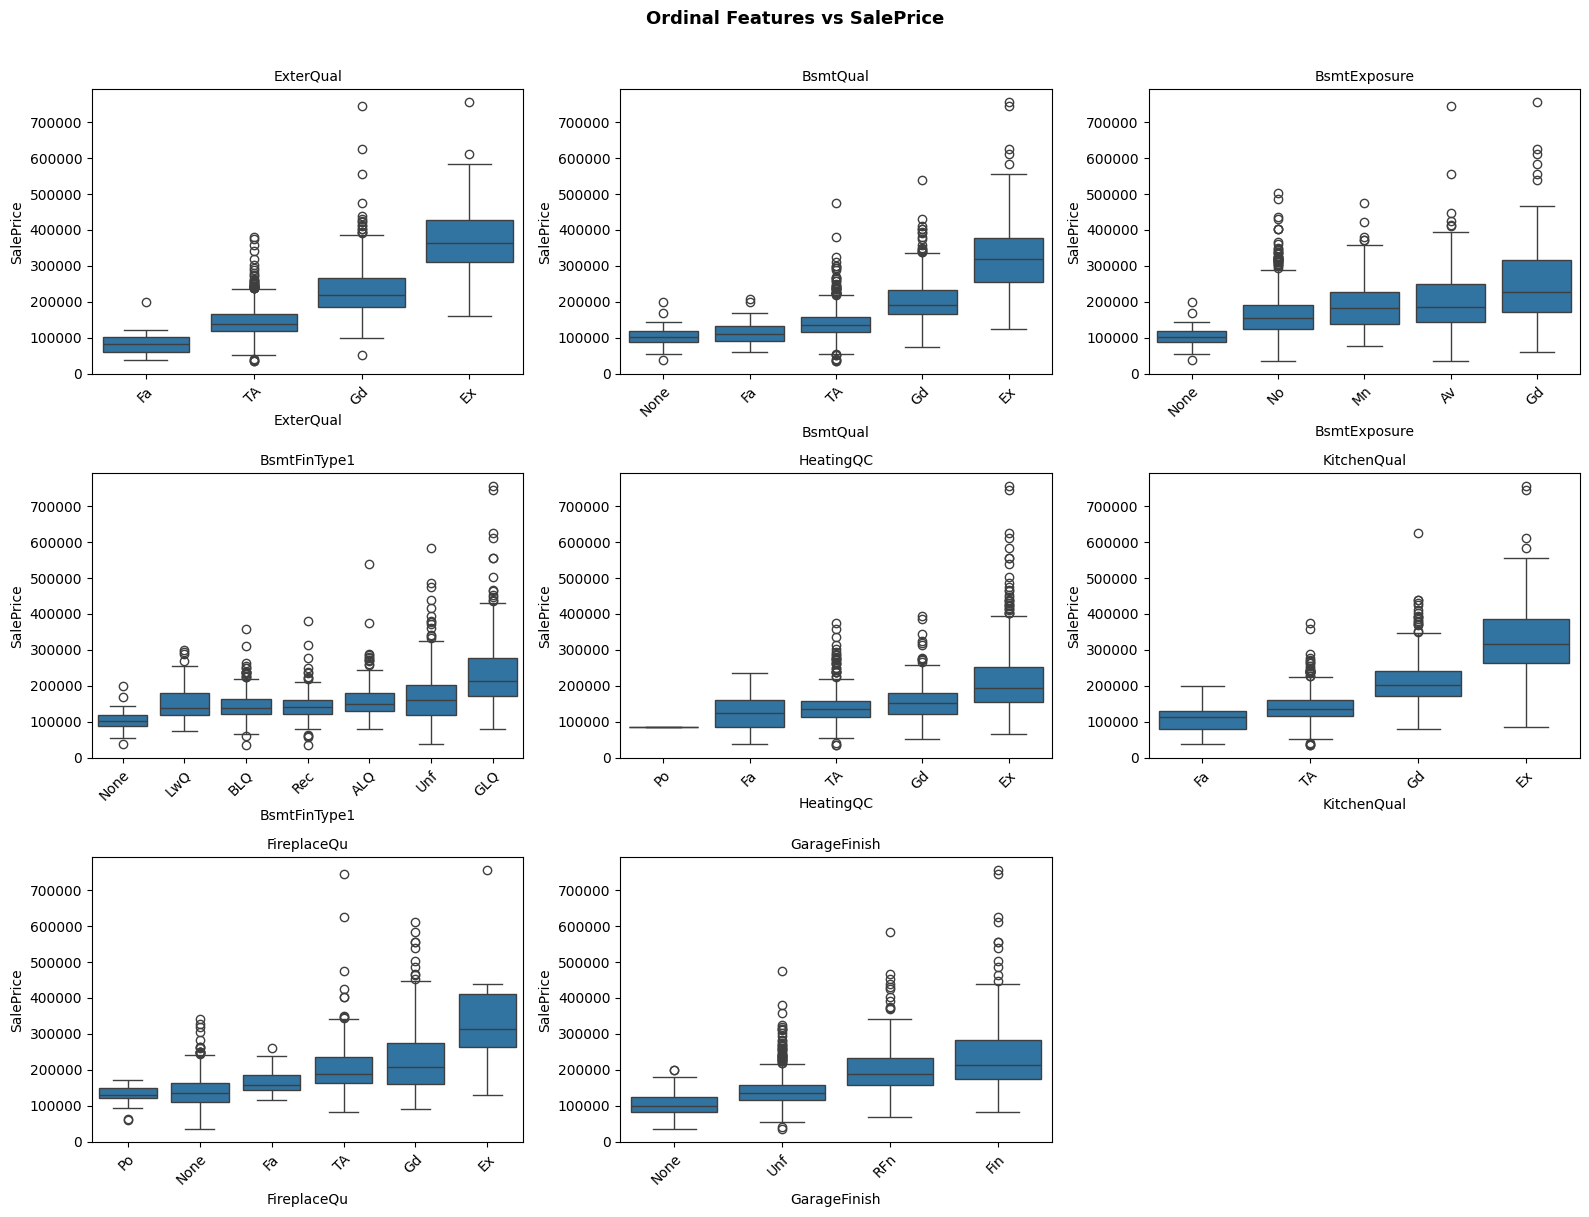

In [47]:
plot_cat_block(ordinal_cols, 'Ordinal Features vs SalePrice', 
               order_fn = lambda col: df_tr.groupby(col)['SalePrice'].median().sort_values().index, 
               n_cols=3, 
               plot_type = "boxplot", 
               target = 'SalePrice')

Most of these features show strong discrimination against the target variable SalePrice. This is expected, since we are reviewing ordinal cases, where the hierarchical order naturally correlates with price. Given the strong pattern with the target, a simple ordinal encoding would suffice, but there are 3 features that need additional handling.

Initially, grouping "Po" with "Fa" was considered for features like `HeatingQ`C and `FireplaceQu`, since both categories have few examples and similar medians. However, a full ordinal encoding (Po=1, Fa=2, TA=3, Gd=4, Ex=5) lets the model decide where to cut..

`BsmtFinType1`: This feature has the weakest variance with the target, but it isn't a big problem. The frequency distribution in BsmtFinType1 is not bad at all, but BsmtFinType2 is dominated by a single category, so the distribution is heavily imbalanced. Given the relationship between basement features, the best approach is to create an extra binary column that identifies whether the property has a basement or not. We could actually do the same for Garage features.

The other features — `ExterQual, KitchenQual, BsmtQual, BsmtExposure`, and `GarageFinish` — show strong ordinal patterns, and as I mentioned, they only require a simple ordinal encoding

### 5.3.3 Date Features vs SalePrice

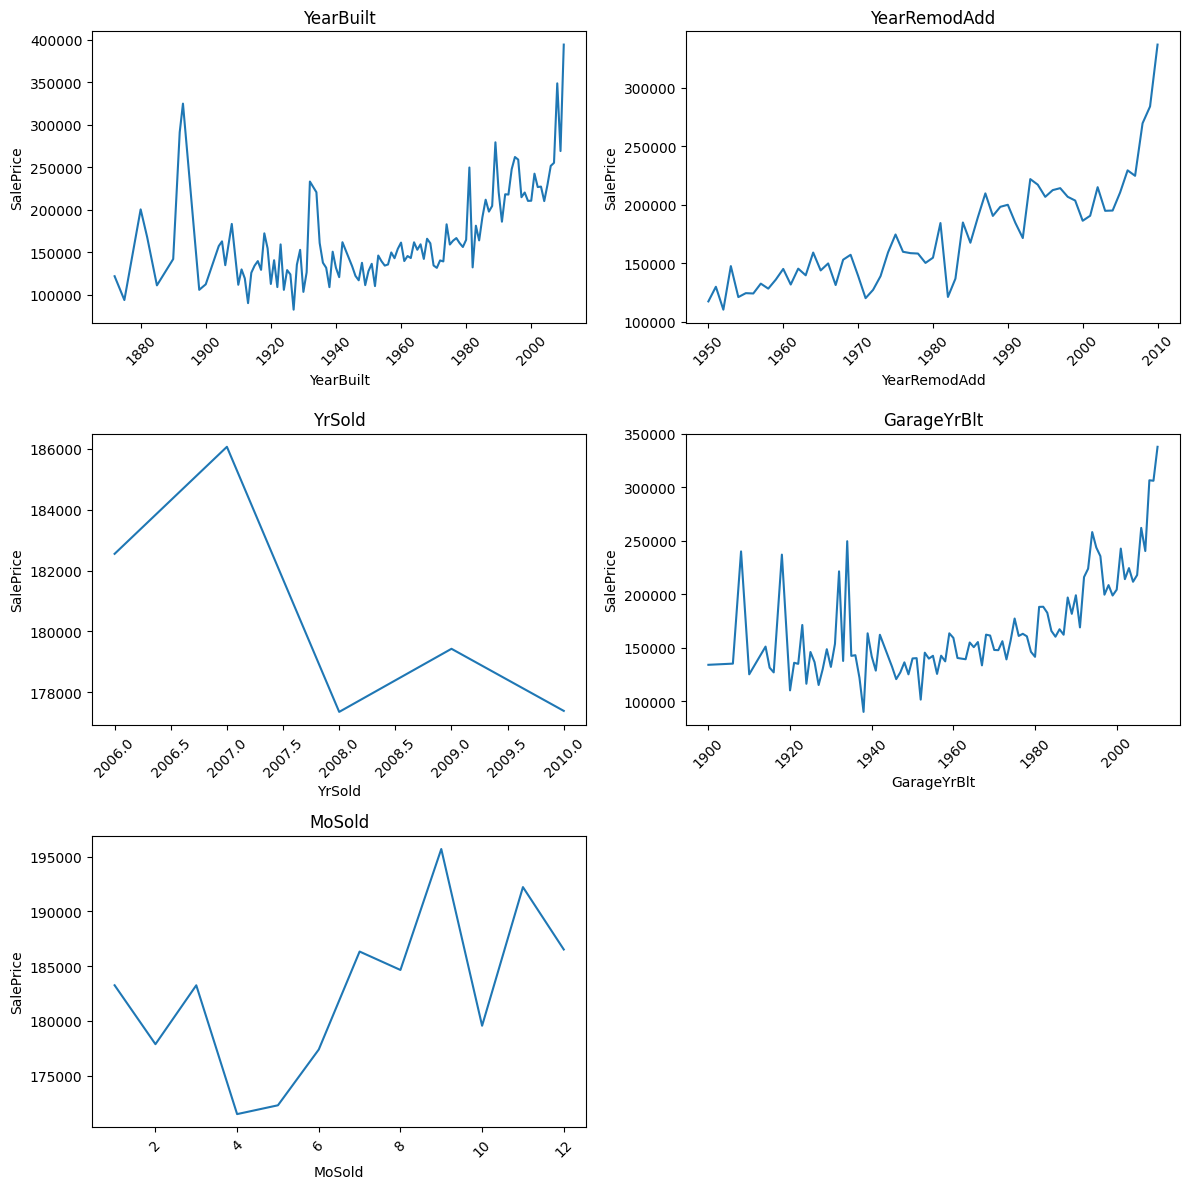

In [48]:
columns = year_cols + ['MoSold']
n_cols = 2
n_rows = math.ceil(len(columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 4))
axes = axes.flatten() 

for i, col in enumerate(columns):
    sns.lineplot(data=data, x=col, y= 'SalePrice', ax=axes[i], errorbar=None)
    axes[i].set_title(f'{col}')
    axes[i].tick_params(axis='x', rotation=45)
    

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

As I mentioned in the univariate analysis, YearBuilt shows that in recent years prices have increased.

We can apply simple Feature Engineering to almost all of these features.

`YearBuilt` and `GarageYrBlt`: We can transform both features into age, using YrSold as a support feature (age = `YrSold` - `YearBuilt` / `GarageYrBlt`).

`YearRemodAdd`: Similarly, we can use YrSold as a support feature to calculate and transform it into "years since last renovation" (YearsSinceRenov = `YrSold` - `YearRemodAdd`). Additionally, we can create a new binary column: WasRemodeled = `YearRemodAdd` != `YearBuilt`.

P.S. Both features keep their original names; "age" and "YearsSinceRenov" are just for demonstration purposes.

`MoSold` and `YrSold` will be deleted.

 ---

Regarding `GarageYrBlt` missing values: a good approach (thanks to the **HasGarage** column) is to impute with -1.

### 5.3.4 Dominant Categories Review

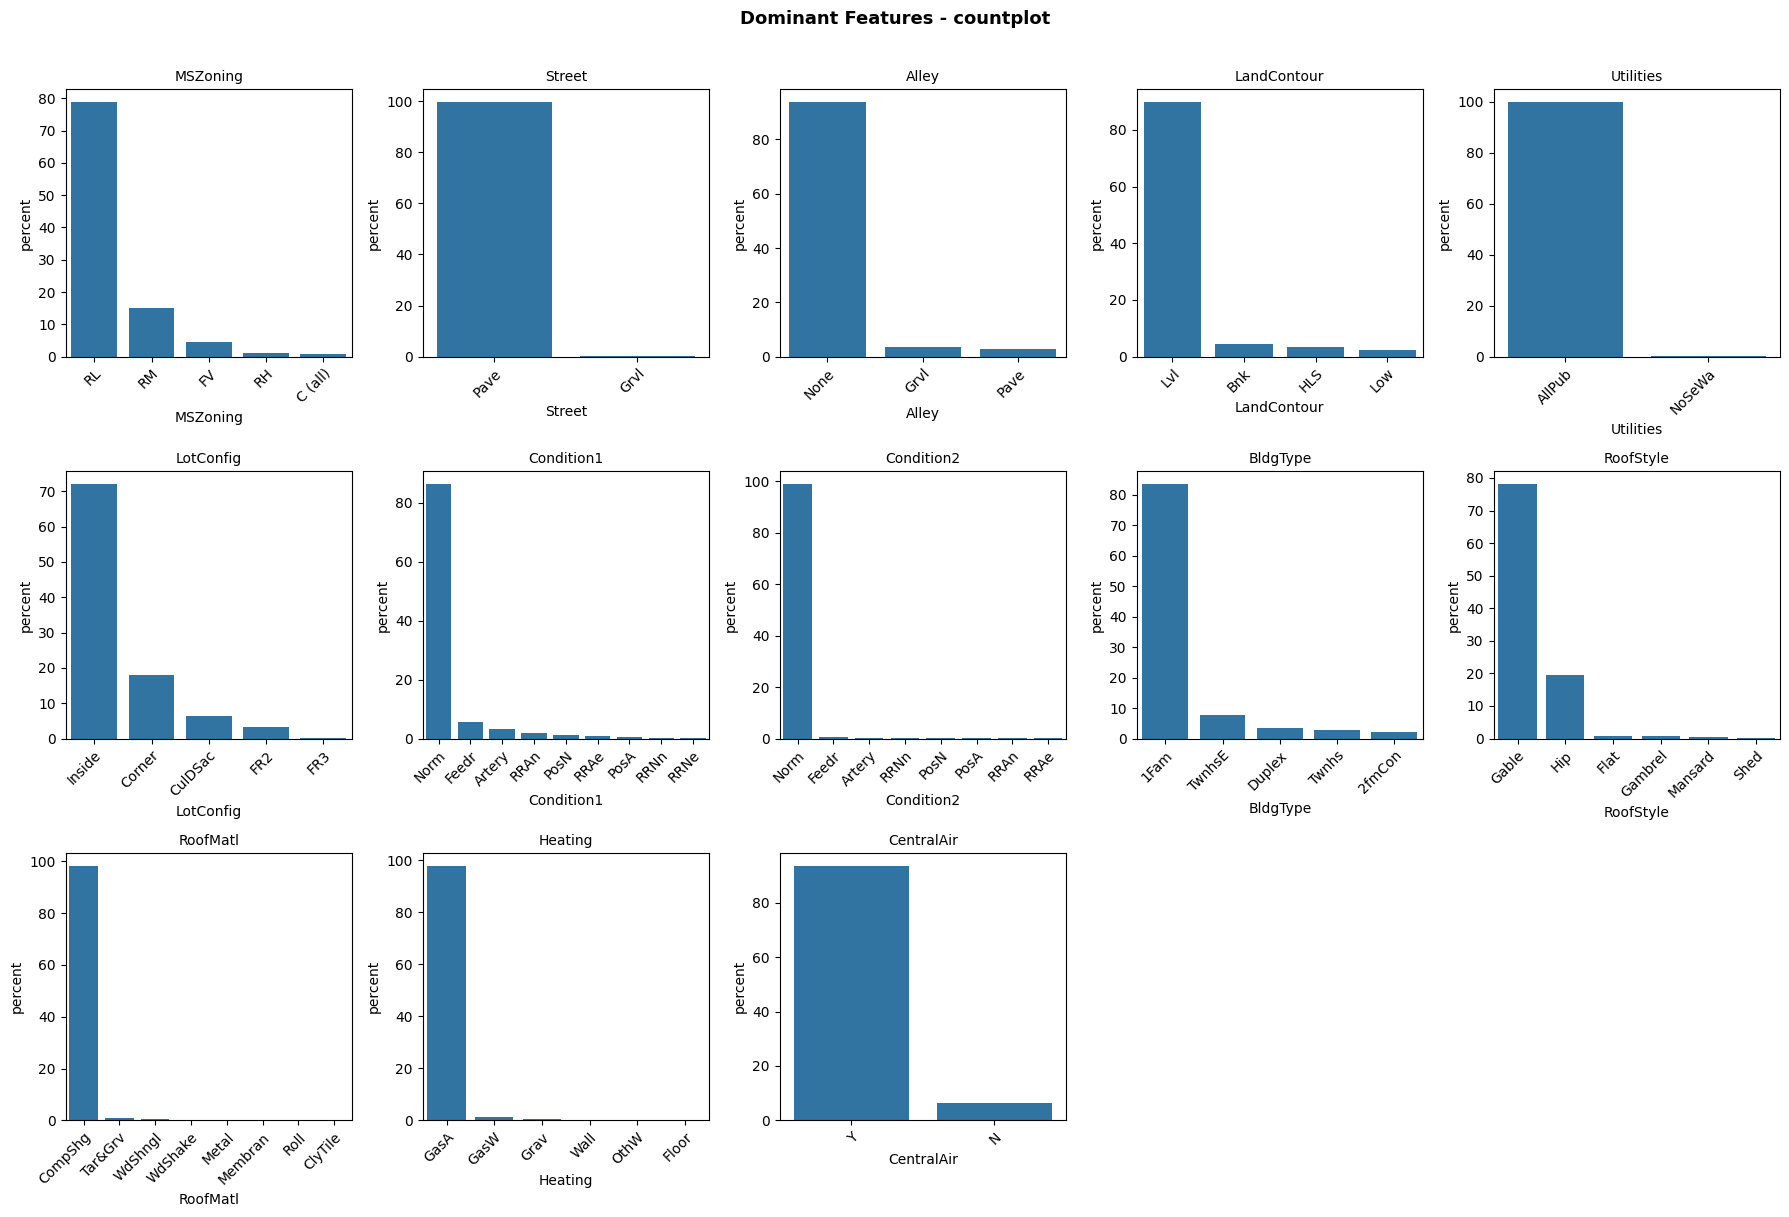

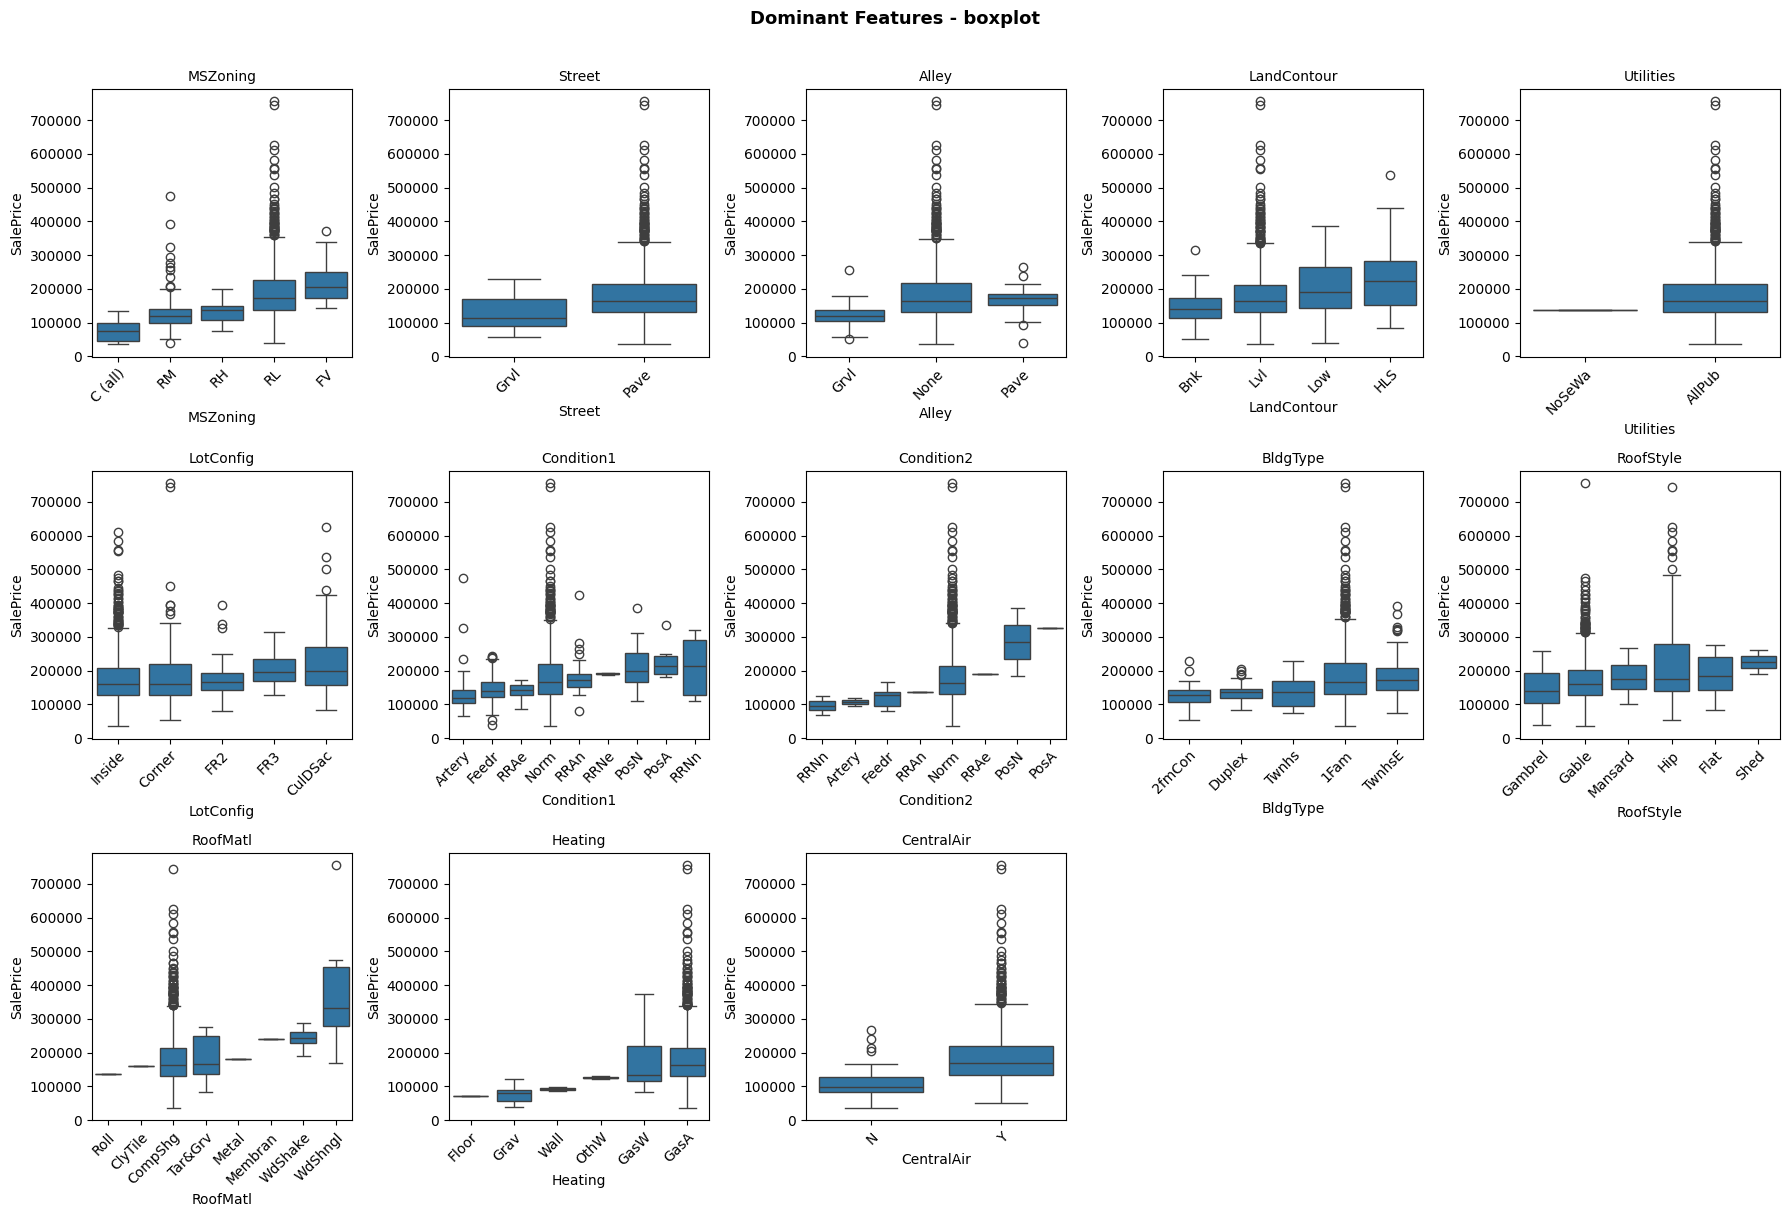

In [49]:
# First half

plot_num_block(dominant_cat[0:len(dominant_cat)//2], 
               'Dominant Features - countplot', 
               n_cols=5, 
               plot_type = "countplot", 
               target = None)

plot_num_block(dominant_cat[0:len(dominant_cat)//2], 
               'Dominant Features - boxplot', 
               n_cols=5, 
               plot_type = "boxplot", 
               target = 'SalePrice')

**Candidates for keep**

- `MsZoning`: *RL* dominates but it doesn't have the highest median, it's *FV*. Although the median distribution across categories is quite good,where *RL* and *FV* medians are higher than the minority categories. It's a good idea group those minor values in 'Others' vs *Fv/RL*.
- `LotConfig`: 70% ~*Inside*, however it doesn't dominate in boxplot, it has the lowest median. The value that make a difference is *CullDSac*. the best approach is to group into *CulDSac* and 'Others'.
- `BldgType`: *1Fam* dominates followed by *TwnhsE* and in boxplot happen something similar, these values show a slightly higher median. The best approach is to binarize as 1Fam/TwnhsE vs Others.
- `Condition1`: *Norm* dominates and unlike `Condition2` has a little more variability in frequency, given the dominance of Norm, I'll group it as *Norm* vs Others.
- `RoofStyle`: Hip roofs, though less common (~19%), show a higher median price. Binarizing as ‘Hip vs Other’ captures the signal better than ‘Gable vs Other’.
- `CentralAir`: Although it's already binary, the median difference between values is significant, keep as is.
___

**Candidates for Drop**

- `Street`: ~99% *Pave*, the boxplot is slightly good, but the problem is the extreme imbalance between categories.
- `Alley`: The dominant category shows a wide spread with many outliers, meaning it doesn't effectively discriminate SalePrice. The minority categories don't show a meaningful median difference either.
- `LandContour`: Similar case — the dominant category contains many outliers, indicating high price variability within the group. Although HLS shows a slightly higher median, the sample size is too small to be reliable. 
- `Utilities`: ~99 *AllPub*, the boxplot isn't reliability.
- `Condition2`: ~99 *Norm* it's a pity it has such poor frequency distribution, because in boxplot present a great discrimination with the target.
- `RoofMatl`: ~ 99 *CompShg* same as Condition2 — it's a pity.
- `Heating`: ~98 *Gasa* poor frequency but a slight good boxplot, the minority values are merely anecdotal.


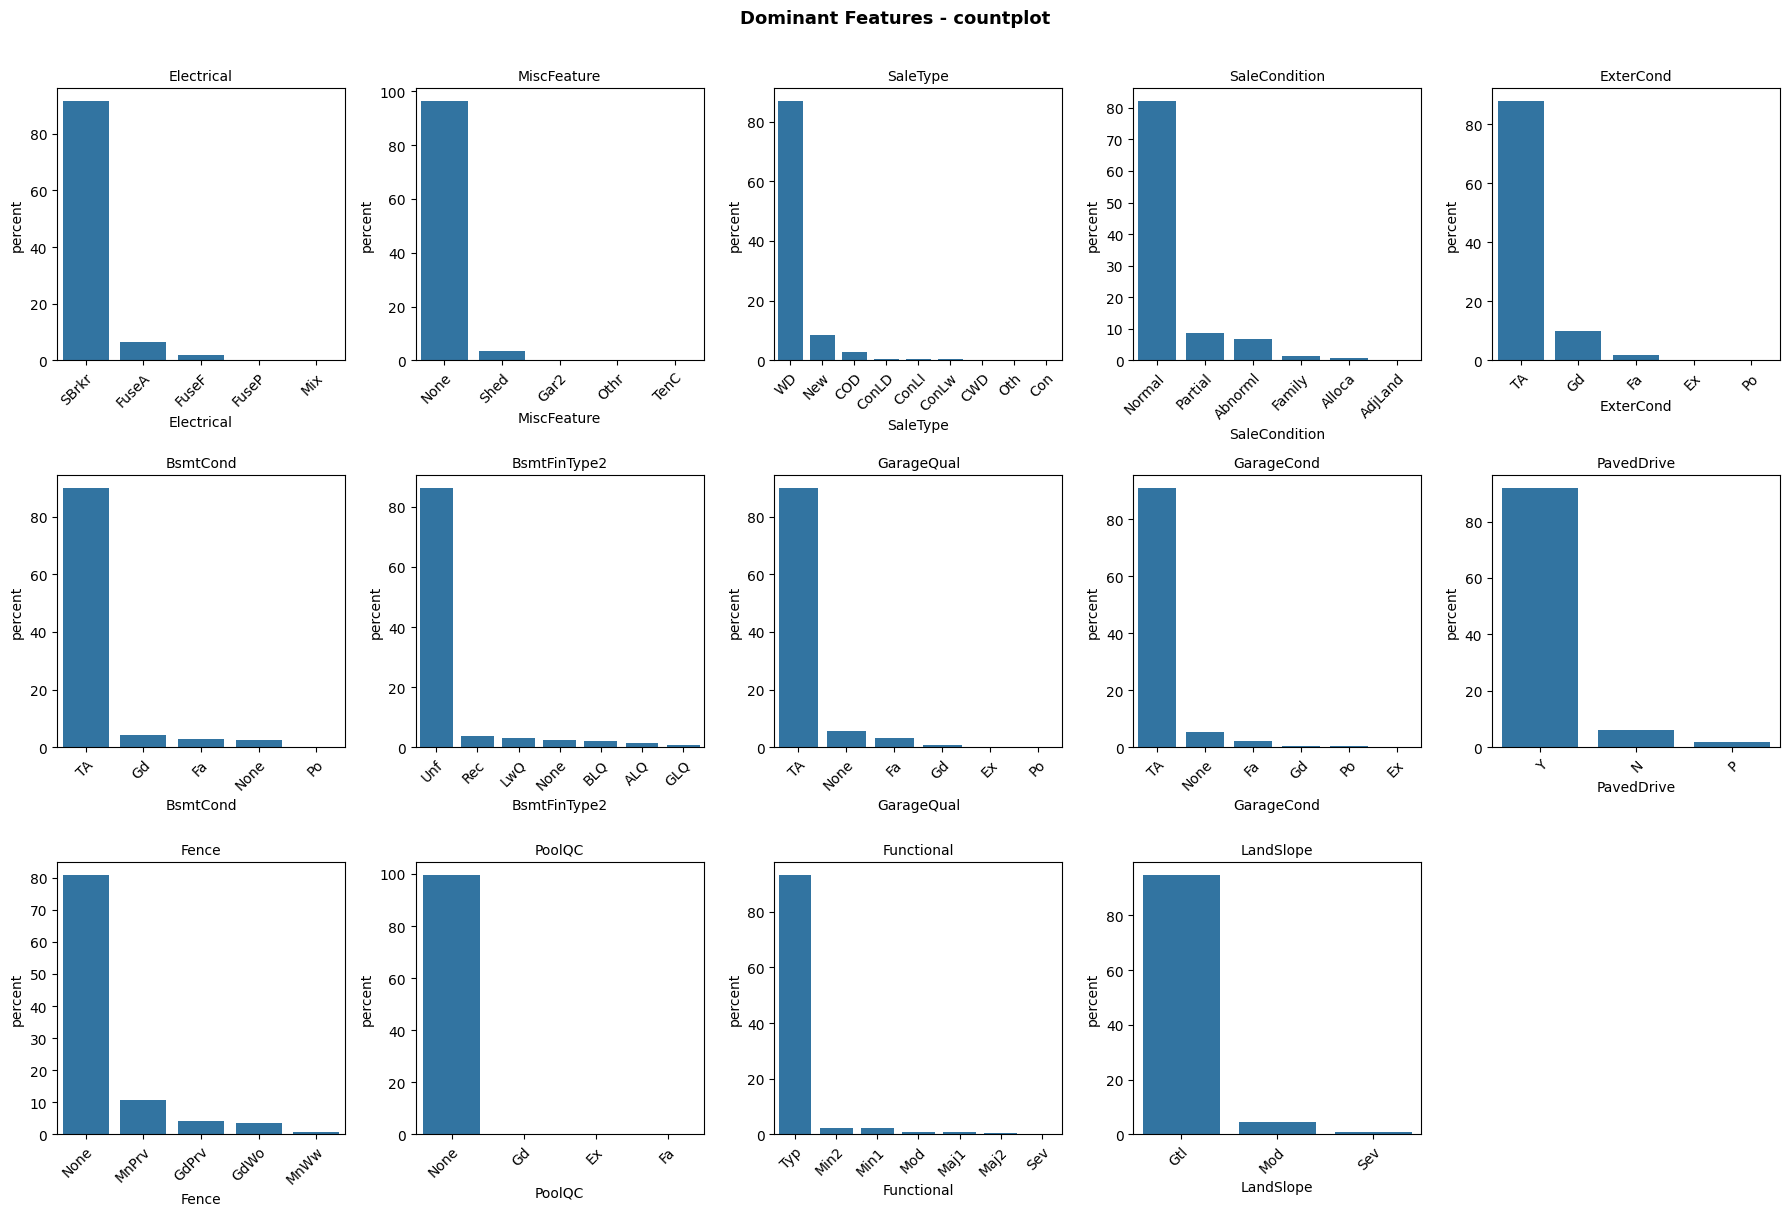

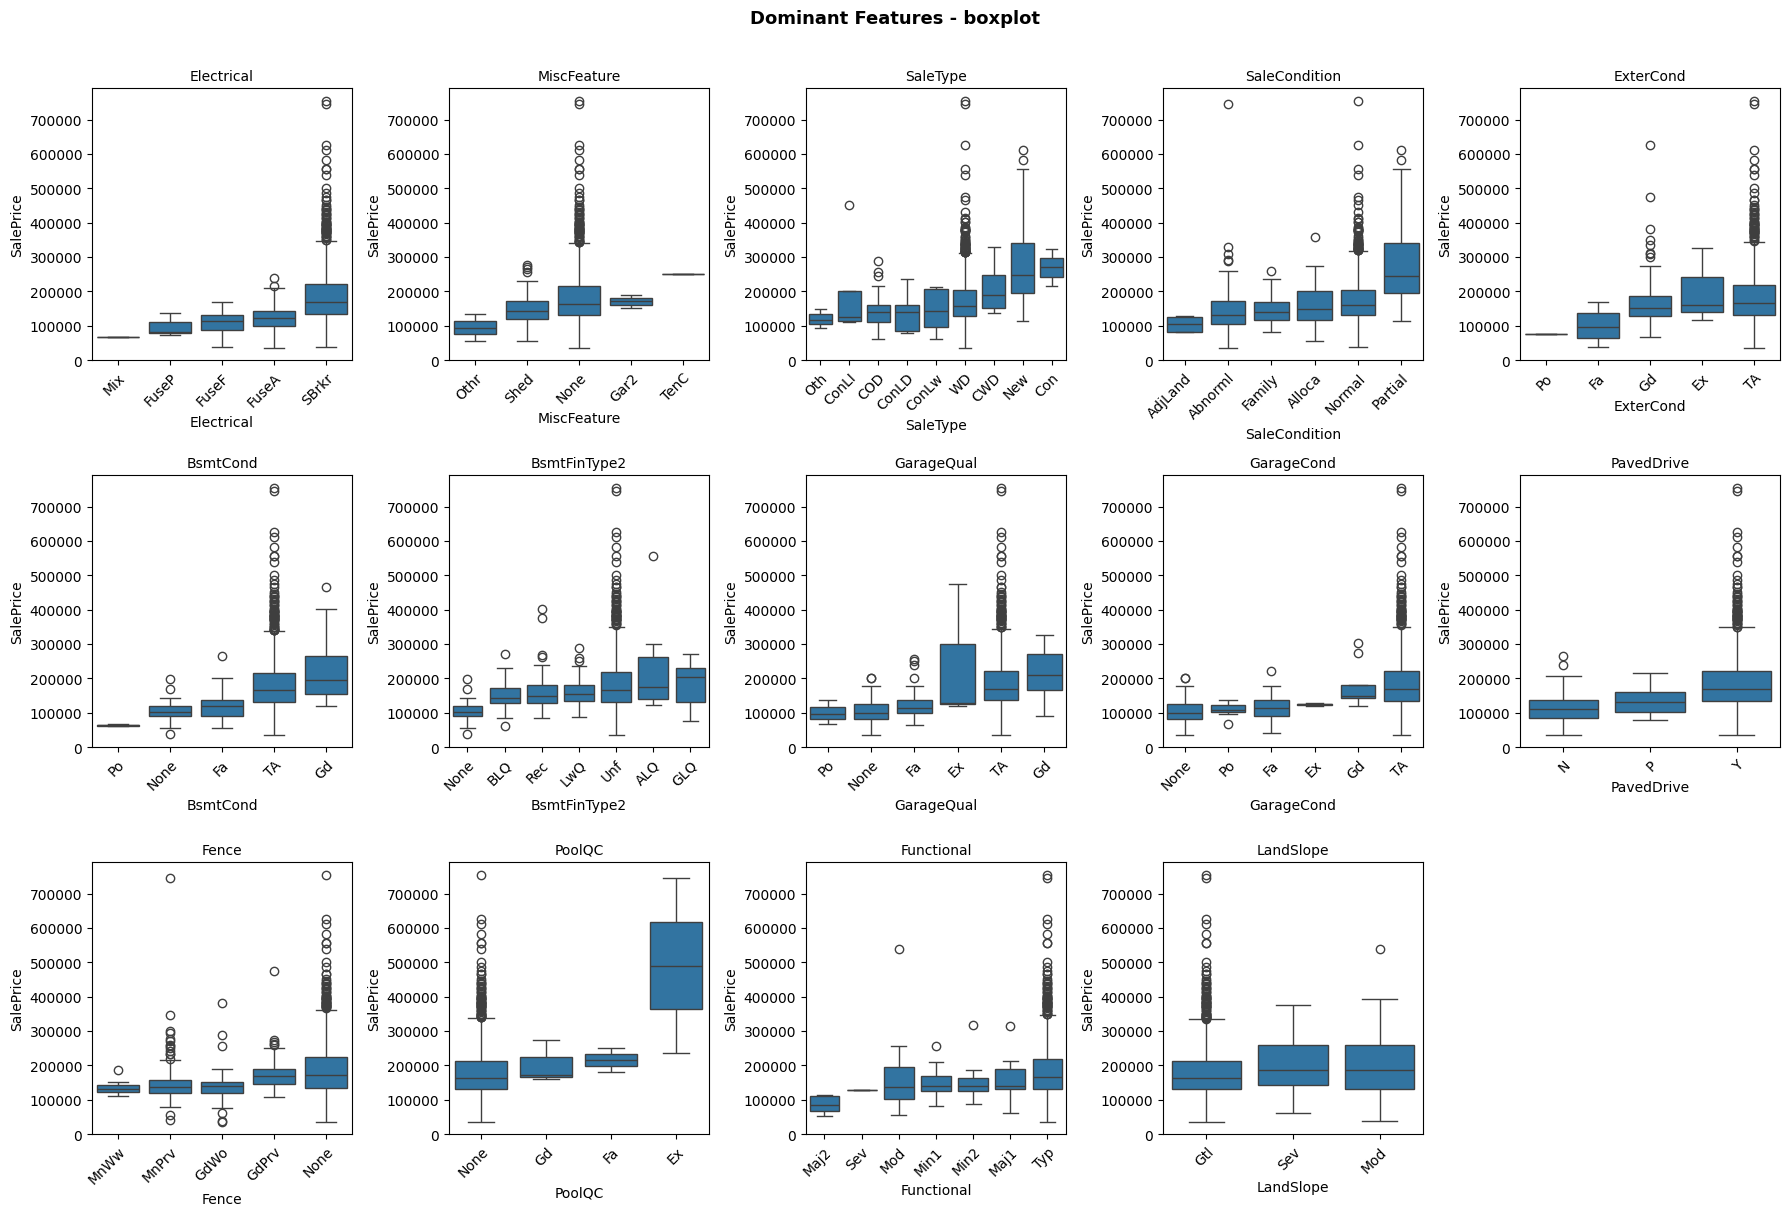

In [50]:
# Second half

plot_num_block(dominant_cat[len(dominant_cat)//2:], 
               'Dominant Features - countplot', 
               n_cols=5, 
               plot_type = "countplot", 
               target = None)

plot_num_block(dominant_cat[len(dominant_cat)//2:], 
               'Dominant Features - boxplot', 
               n_cols=5, 
               plot_type = "boxplot", 
               target = 'SalePrice')

**Candidates for keep**

- `Electrical`: ~90% *SBrkr* dominates, while the other values reach ~10%. However the median distribution across categories is good. The difference between SBrkr's median is higher than the others values.The approach here is transform the feature to binary column *SBrkr* and 'Others'.
- `SaleCondition`: ~80% *Normal* dominates followed by *Partial*. In the boxplot Partial has the highest median and the rest share a similar median.We could transform it into a binary column *Partial* and 'Others'.
- `SaleType`: ~85% *WD*, but ‘New’ has a much higher median. This makes it highly predictive. The approach is binarize as ‘New vs Other’.
- `BsmtCond`: ~90% *Ta* dominates while *Po* is close to 0%. Let's try to salvage this feature, because the median variance could help the model find some signal. The only approach is apply an ordinal label encoding.
- `PavedDrive`: ~90% *Y* dominates. However the boxplot shows a great discrimination. *Y* has the largest median, while the other values decrease. The approach is keep it as is and apply and just apply a simple ordinal label encoding.

---

**Candidates for drop**

- `MiscFeature`: Shows great median variance, but the values with higher medians have fewer than ~5% of examples.
- `ExterCond`: The medians are very similar between *TA*, *EX* and *Gd*. The signal is poor.
- `BsmtFinType2`: It is redundant to manage or keep this feature, since we already have a better one — `BsmtFinType1`.
- `GarageQual - GarageCond`: Both are redundant and show poor signal, unlike `GarageFinish - HasGarage`.
- `Fence`: We could try to save this, but it doesn't have a clear pattern.
- `PoolQC`: ~99% *None* the other values are merely anecdotal.
- `Functional`: The majority of values have a similar median, although the frequency distribution doesn't help either.
- `LandSlope`: Its 3 values have similar medians, making it hard to find any signal.


# 6. Conclusion: Feature Engineering Plan


After analyzing every feature through univariate distributions, bivariate relationships with SalePrice, and frequency balance, here is the consolidated plan for feature engineering before training the model.

---

## 6.1 Features to Drop

| Feature | Reason |
|---------|--------|
| `Exterior2nd` | Redundant with `Exterior1st` (replaced by `SameMaterial`) |
| `MoSold` | Weakest variance with SalePrice — seasonal volume but no price signal |
| `YrSold` | Only 5 years of range, used as support for age calculations then dropped |
| `Street` | ~99% Pave, extreme imbalance with no meaningful boxplot difference |
| `Alley` | ~93% None, no meaningful median difference in minority categories |
| `LandContour` | ~90% Lvl, HLS slightly higher but too few examples |
| `Utilities` | ~99% AllPub, unreliable boxplot |
| `Condition2` | ~99% Norm, great boxplot but unusable frequency |
| `RoofMatl` | ~99% CompShg, same issue as Condition2 |
| `Heating` | ~98% GasA, minority values are merely anecdotal |
| `MiscFeature` | ~95% None, interesting medians but <5% frequency in minority |
| `ExterCond` | Similar medians between TA/Gd/Ex, poor signal |
| `BsmtFinType2` | Redundant with `BsmtFinType1` |
| `GarageQual` | Redundant — poor signal, already have `GarageFinish` + `HasGarage` |
| `GarageCond` | Redundant — same as `GarageQual` |
| `Fence` | No clear pattern, None has highest median (counterintuitive) |
| `PoolQC` | ~99% None, other values are anecdotal |
| `Functional` | ~90% Typ, similar medians across categories |
| `LandSlope` | 3 values with similar medians, no signal |
| `LowQualFinSF` | Zero-inflated, non-zero values show no trend with SalePrice |
| `PoolArea` | Zero-inflated, no meaningful trend |
| `MiscVal` | Zero-inflated, no meaningful trend |
| `BsmtFinSF2` | Zero-inflated, no meaningful trend |
| `3SsnPorch` | Zero-inflated, no meaningful trend |
| `YearRemodAdd ` | Redundant with `YearsSinceRenov ` |
---

## 6.2 New Features to Create

| New Feature | Source | Logic |
|-------------|--------|-------|
| `SameMaterial` | `Exterior1st`, `Exterior2nd` | Boolean: Exterior1st == Exterior2nd |
| `HasBasement` | Basement features | Boolean: identifies if the property has a basement |
| `HasGarage` | Garage features | Boolean: identifies if the property has a garage |
| `WasRemodeled` | `YearRemodAdd`, `YearBuilt` | Boolean: YearRemodAdd != YearBuilt |
| `IsSplitLevel` | `HouseStyle` | Boolean: HouseStyle in (SFoyer, SLvl) |
| `NumLevels` | `HouseStyle` | Numeric: 1, 1.5, 2, 2.5 (SFoyer=1, SLvl=1.5) |
| `IsFinished` | `HouseStyle` | Boolean: finished status (SFoyer/SLvl count as finished) |
| `HasFireplace` | `Fireplaces` | Boolean: Fireplaces > 0 |
| `TotalBath` | Bath features | FullBath + BsmtFullBath + 0.5*(HalfBath + BsmtHalfBath) |
| `TotalPorchSF` | Porch features | WoodDeckSF + OpenPorchSF + EnclosedPorch + ScreenPorch |
| `OverallC_is5` | `OverallCond` | Boolean: OverallCond == 5 |

**Note**: `TotalBuiltArea` was added later during model iteration after observing 
that combining the three main area features improved the validation score.

---

## 6.3 Transformations on Existing Features

### 6.3.1 Year Features → Age Conversion
| Feature | Transformation | NaN Handling |
|---------|---------------|--------------|
| `YearBuilt` | `YrSold - YearBuilt` (age at sale) | No NaN |
| `YearRemodAdd` | `YrSold - YearRemodAdd` (years since last renovation) | No NaN |
| `GarageYrBlt` | `YrSold - GarageYrBlt` (garage age) | Impute NaN with -1 (used with `HasGarage`) |

### 6.3.2 Grouping Rare Categories
| Feature | Action |
|---------|--------|
| `Exterior1st` | Group rare categories into 'Others' |
| `Foundation` | Group Stone/Wood/Slab into 'Others' → 3 categories: PConc, CBlock, Others |

### 6.3.3 Target Encoding
| Feature | Action |
|---------|--------|
| `Neighborhood` | Target encoding OOF (5 folds) + smoothing k=10 |
| `MSSubClass` | Target encoding OOF (5 folds) + smoothing k=10 |

### 6.3.4 Binarization
| Feature | Binary Split |
|---------|-------------|
| `LotShape` | Regular vs Irregular |
| `CentralAir` | Y=1, N=0 |
| `MSZoning` | 3 categories: RL, FV, Others |
| `LotConfig` | CulDSac vs Others |
| `BldgType` | 1Fam/TwnhsE vs Others |
| `Condition1` | Norm vs Others |
| `RoofStyle` | Hip vs Others |
| `Electrical` | SBrkr vs Others |
| `SaleCondition` | Partial vs Others |
| `SaleType` | New vs Others |
| `KitchenAbvGr` | Binary: 1 vs 2+ |

 ### 6.3.5 Ordinal Encoding
| Feature | Order |
|---------|-------|
| `ExterQual` | Fa=0, TA=1, Gd=2, Ex=3 |
| `KitchenQual` | Fa=0, TA=1, Gd=2, Ex=3 |
| `BsmtQual` | None=0, Fa=1, TA=2, Gd=3, Ex=4 |
| `BsmtExposure` | None=0, No=1, Mn=2, Av=3, Gd=4 |
| `GarageFinish` | None=0, Unf=1, RFn=2, Fin=3 |
| `HeatingQC` | Po= 0, Fa=1, TA=2, Gd=3, Ex=4 |
| `FireplaceQu` | None=0, Po=1, fa=2, TA=3, Gd=4, Ex=5 |
| `BsmtFinType1` | None=0, LwQ=1, BLQ=2, Rec=3, ALQ=4, Unf=5, GLQ=6 |
| `BsmtCond` | None= 0, Po=1, Fa=2, TA=3, Gd=4 |
| `MasVnrType` | None=0, BrkCmn=1, BrkFace=2, Stone=3 |
| `GarageType` | None=0, CarPort=1, Detchd=2, Basment=3, Attchd=4, BuiltIn=5 |
| `PavedDrive` | N=0, P=1, Y=2 |

### 6.3.6 Discrete Features (Retain)
| Feature | Action |
|---------|--------|
| `OverallQual` | Keep as-is (strongest predictor) |
| `OverallCond` | Keep as-is + create `OverallC_is5` |
| `FullBath` | Replaced by `TotalBath` (drop original bath features) |
| `BedroomAbvGr` | Keep as-is, monitor extreme values |
| `Fireplaces` | Keep as-is + create `HasFireplace` |
| `GarageCars` | Keep as-is (strong consistent signal) |

 ### 6.3.7 Continuous Features (Retain)
| Feature | Notes |
|---------|-------|
| `GrLivArea` | Strong positive correlation — top predictor |
| `1stFlrSF` | Strong positive correlation |
| `TotalBsmtSF` | Strong positive correlation |
| `BsmtFinSF1` | Strong positive correlation |
| `LotArea` | Moderate correlation, retain |
| `LotFrontage` | Moderate correlation, retain |
| `MasVnrArea` | Retain — non-zero values show positive trend |
| `2ndFlrSF` | Retain — non-zero values show positive trend |
| `GarageArea` | Retain — positive correlation |
| `BsmtUnfSF` | Retain |

---

## 6.4 Flagged Missing Values (Pending Inspection)
- `GarageYrBlt`: Impute NaN with -1 

## 6.5 Flagged Outliers 
- `BsmtFinSF1`: One point above 5,000 with surprisingly low price
- `LotArea`: Three outliers with large area but low price
- `TotalBsmtSF` / `1stFlrSF`: One moderate outlier each

---


In [51]:
idx_drop = flagged['GrLivArea'].union(flagged['LotArea'])
print(f'Rows to drop: {len(idx_drop)}')
display(df_tr.loc[idx_drop, ['GrLivArea', 'LotArea', 'SalePrice']])


df_tr = df_tr.drop(index = idx_drop).reset_index(drop = True)

Rows to drop: 4


,GrLivArea,LotArea,SalePrice
249,2144,159000,277000
335,1786,164660,228950
523,4676,40094,184750
1298,5642,63887,160000


# 7. Preprocessing (Test set)

All cleaning logic from section 4 was applied to df_tr. Here we replicate it on df_te using statistics from train to avoid leakage

## 7.1 Structural NaN → "None" Imputation

In [52]:
imputation_none(df_te, cols_nan_is_none)
missing_table(df_te)

,Missing Count,Missing Percent
LotFrontage,227,15.6
GarageYrBlt,78,5.3
MasVnrArea,15,1.0
MSZoning,4,0.3
BsmtFullBath,2,0.1
Utilities,2,0.1
BsmtHalfBath,2,0.1
Functional,2,0.1
Exterior1st,1,0.1
Exterior2nd,1,0.1


## 7.2 Domain-Specific Imputation

In [53]:
rng = np.random.RandomState(SEED)

def impute_lotfrontage(df, ref_df, rng):
    for neigh in df['Neighborhood'].unique():
        mask = (df['Neighborhood'] == neigh) & df['LotFrontage'].isnull()
        n_missing = mask.sum()
        if n_missing == 0:
            continue
        pool = ref_df.loc[ref_df['Neighborhood'] == neigh, 'LotFrontage'].dropna().values
        if len(pool) == 0:
            pool = ref_df['LotFrontage'].dropna().values
        df.loc[mask, 'LotFrontage'] = rng.choice(pool, size=n_missing, replace=True)
    return df

df_te = impute_lotfrontage(df_te, df_tr, rng)

In [54]:
# Fallback Imputation
for col in df_te.columns:
    if df_te[col].isnull().any():
        if df_te[col].dtype == 'object':
            df_te[col] = df_te[col].fillna(df_tr[col].mode()[0])
        else:
            df_te[col] = df_te[col].fillna(df_tr[col].median())

# 8. Feature Engineering

## 8.1 Create New Features

In [55]:
def new_features(df):
        
    df['SameMaterial'] = (df['Exterior1st'] == df['Exterior2nd']).astype(int)
    df['HasBasement'] = (df.BsmtQual != 'None').astype(int)
    df['HasGarage'] = (df['GarageType'] != 'None').astype(int)
    df['WasRemodeled'] = (df['YearRemodAdd'] != df['YearBuilt']).astype(int)
   
    # HouseStyle
    levels_map = {
    '1Story': 1, '1.5Fin': 1.5, '1.5Unf': 1.5,
    '2Story': 2, '2.5Fin': 2.5, '2.5Unf': 2.5,
    'SFoyer': 1, 'SLvl': 1.5
    }
    
    df['IsSplitLevel'] = df['HouseStyle'].isin(['SFoyer', 'SLvl']).astype(int)
    df['NumLevels'] = df['HouseStyle'].map(levels_map).fillna(1)
    df['IsFinished'] = np.where(df['HouseStyle'].str.contains('Unf', na=False), 0, 1)
    # End HouseStyle
    
    df['HasFireplace'] = (df['Fireplaces'] > 0).astype(int)
    df['TotalBath'] = df['FullBath'] + df['BsmtFullBath'] + 0.5 * (df['HalfBath'] + df['BsmtHalfBath'])  
    df['TotalPorchSF'] = df['WoodDeckSF'] + df['OpenPorchSF'] + df['EnclosedPorch'] + df['ScreenPorch'] 
    df['OverallC_is5'] =  (df['OverallCond'] == 5).astype(int)
    df['TotalBuiltArea'] = df['GrLivArea'] + df['TotalBsmtSF'] + df['GarageArea']

    return df



## 8.2 Transformations on Existing Features

In [56]:
def transf_ef(df):
    
    df['YearBuilt'] = df['YrSold'] - df['YearBuilt']
    df['GarageYrBlt'] = df['YrSold'] - df['GarageYrBlt']
    df['YearsSinceRenov'] = df['YrSold'] - df['YearRemodAdd']
    df['GarageYrBlt'] = df['GarageYrBlt'].fillna(-1)

    return df

## 8.3 Grouping Rare Categories and Binarization


In [57]:


def group_rare_cat(df):
    counts_ext1 = df_tr['Exterior1st'].value_counts()
    keep_ext1 = counts_ext1[counts_ext1 >= 20].index
    df['Exterior1st'] = df['Exterior1st'].where(df['Exterior1st'].isin(keep_ext1), 'Others')
    df['Foundation'] = df['Foundation'].where(df['Foundation'].isin(['PConc', 'CBlock']), 'Others')
    df['MSZoning'] = df['MSZoning'].where(df['MSZoning'].isin(['RL', 'FV']), 'Others')
    
    return df


def binarization(df):

    df['LotShape'] = (df['LotShape'] == 'Reg').astype(int)  
    df['CentralAir'] = df['CentralAir'].replace({'Y':1, 'N':0}).astype(int)
    df['LotConfig'] = df['LotConfig'].isin(['CulDSac']).astype(int)
    df['BldgType'] = df['BldgType'].isin(['1Fam','TwnhsE']).astype(int)
    df['Condition1'] = df['Condition1'].isin(['Norm']).astype(int)
    df['RoofStyle'] = df['RoofStyle'].isin(['Hip']).astype(int)
    df['Electrical'] = df['Electrical'].isin(['SBrkr']).astype(int)
    df['SaleCondition'] = df['SaleCondition'].isin(['Partial']).astype(int)
    df['SaleType'] = df['SaleType'].isin(['New']).astype(int)
    df['KitchenAbvGr'] = np.where(df['KitchenAbvGr'] <= 1, 0, 1)

    return df


In [58]:
df_tr = new_features(df_tr)
df_tr = transf_ef(df_tr)
df_tr = group_rare_cat(df_tr)
df_tr = binarization(df_tr) 

In [59]:
df_te = new_features(df_te)
df_te = transf_ef(df_te)
df_te = group_rare_cat(df_te)
df_te = binarization(df_te)  

# 8.4 Feature Encoding

In [60]:
def k_fold_targett_encoding(df_tr, df_te, col, target, n_splits=5, smoothing=10, seed=SEED):
    global_mean = df_tr[target].mean()
    kf = KFold(n_splits=n_splits, shuffle = True, random_state = seed)

    tr_encoded = np.zeros(len(df_tr))

    for (tr_idx, val_idx) in kf.split(df_tr):
        agg = df_tr.iloc[tr_idx].groupby(col)[target].agg(['mean', 'count'])

        smooth = (agg['mean'] * agg['count'] + global_mean * smoothing) / (agg['count'] + smoothing)
        tr_encoded[val_idx] = df_tr.iloc[val_idx][col].map(smooth).fillna(global_mean).values

    agg_full = df_tr.groupby(col)[target].agg(['mean', 'count'])
    smooth_full = (agg_full['mean'] * agg_full['count'] + global_mean * smoothing) / (agg_full['count'] + smoothing)
    te_encoded = df_te[col].map(smooth_full).fillna(global_mean).values

    return tr_encoded, te_encoded

df_tr['_y_log'] = np.log1p(df_tr['SalePrice'])

for col in ['Neighborhood', 'MSSubClass']:
    tr_enc, te_enc = k_fold_targett_encoding(df_tr, df_te, col, '_y_log')
    df_tr[col] = tr_enc
    df_te[col] = te_enc

df_tr = df_tr.drop(columns=['_y_log'])

## 8.5 Ordinal Encoding

In [61]:
quality_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

quality_cols = ['ExterQual', 'KitchenQual', 'BsmtQual', 'BsmtCond', 
                'HeatingQC', 'FireplaceQu']

individual_maps = {
    'BsmtExposure': {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4},
    'GarageFinish': {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3},
    'BsmtFinType1': {'None': 0, 'LwQ': 1, 'BLQ': 2, 'Rec': 3, 'ALQ': 4, 'Unf': 5, 'GLQ': 6},
    'MasVnrType':   {'None': 0, 'BrkCmn': 1, 'BrkFace': 2, 'Stone': 3},
    'GarageType':   {'None': 0, 'CarPort': 1, 'Detchd': 2, 'Basment': 3, 'Attchd': 4, 'BuiltIn': 5},
    'PavedDrive':   {'N': 0, 'P': 1, 'Y': 2},
}

def ordinal_enc(df):
    for col in quality_cols:
        df[col] = df[col].map(quality_map).fillna(0)
    for col, mapping in individual_maps.items():
        df[col] = df[col].map(mapping).fillna(0)
    return df

In [62]:
df_tr = ordinal_enc(df_tr)
df_te = ordinal_enc(df_te)

## 8.6 Label Encoding

In [63]:
label_encoders = {}

for col in ['MSZoning', 'Exterior1st', 'Foundation']:
    le = LabelEncoder()
    df_tr[col] = le.fit_transform(df_tr[col])
    label_encoders[col] = le

#  Latest for test:
for col, le in label_encoders.items():
     df_te[col] = le.transform(df_te[col])

 ## 8.7 Drop Columns

In [64]:
drop_col = ['Exterior2nd', 'MoSold', 'YrSold', 'Street', 'Alley', 
             'LandContour', 'Utilities', 'Condition2', 'RoofMatl', 
             'Heating', 'MiscFeature', 'ExterCond', 'BsmtFinType2',
             'GarageQual', 'GarageCond', 'Fence', 'PoolQC', 
             'Functional', 'LandSlope', 'LowQualFinSF', 'PoolArea',
             'MiscVal', 'BsmtFinSF2', '3SsnPorch', 'HouseStyle',
             'FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath',
             'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', 'ScreenPorch', 'YearRemodAdd']

df_tr = df_tr.drop(columns = drop_col)
df_te = df_te.drop(columns = drop_col)

print(df_tr.shape)
print(df_te.shape)


(1456, 60)
(1459, 59)


# 9. Model

 ## 9.1 Setup (X/y Definition)

In [65]:
import xgboost as xgb

X = df_tr.drop(columns=['SalePrice', 'Id'])
X_test = df_te.drop(columns=['Id'])
y = np.log1p(df_tr['SalePrice'])

In [66]:
from scipy.stats import skew

num_feats = X.select_dtypes(include=[np.number]).columns
skew_candidates = [c for c in num_feats
                   if X[c].nunique() > 10
                   and not c.endswith('_te')]

skews = X[skew_candidates].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
high_skew = skews[skews > 0.75].index.tolist()

for c in high_skew + ['TotalBuiltArea']:
    X[c] = np.log1p(X[c].clip(lower=0))
    X_test[c] = np.log1p(X_test[c].clip(lower=0))


print(f'Skew transformadas: {high_skew}')
print(f'X max values: {X[high_skew].max().round(2).to_dict()}')


Skew transformadas: ['LotArea', 'MasVnrArea', 'LotFrontage', 'TotalPorchSF', 'GrLivArea', 'BsmtUnfSF', '1stFlrSF', '2ndFlrSF', 'BsmtFinSF1']
X max values: {'LotArea': 12.28, 'MasVnrArea': 7.38, 'LotFrontage': 5.75, 'TotalPorchSF': 6.94, 'GrLivArea': 8.41, 'BsmtUnfSF': 7.76, '1stFlrSF': 8.08, '2ndFlrSF': 7.63, 'BsmtFinSF1': 7.69}


 ## 9.2 Tuning Model

In [67]:
kf = KFold(n_splits=10, shuffle=True, random_state=SEED)

In [68]:

import optuna
from optuna.samplers import TPESampler


optuna.logging.set_verbosity(optuna.logging.WARNING)  

def objective(trial):
    params = {
        'objective': 'reg:squarederror',
        'n_estimators': 1000,
        'learning_rate': 0.05,
        'max_depth': 3,                    
        'min_child_weight': 3,             
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha',  1e-4, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'gamma':            trial.suggest_float('gamma', 1e-4, 1.0, log=True),
        'random_state': SEED,
        'tree_method': 'hist',
        'device': 'cuda',
    }

    model = xgb.XGBRegressor(**params)
    scores = -cross_val_score(model, X, y, scoring='neg_root_mean_squared_error', cv=kf)
    return scores.mean()

study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=SEED),
    study_name='xgb_tuning',
)

study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\nBest RMSE: {study.best_value:.5f}')
print(f'Best params: {study.best_params}')


  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:774: UserWarning: [08:19:50] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



Best RMSE: 0.11337
Best params: {'subsample': 0.5016207069735619, 'colsample_bytree': 0.408962924617703, 'reg_alpha': 0.17795690948017806, 'reg_lambda': 0.5039721093589102, 'gamma': 0.02567413998505627}


In [69]:

X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.15, random_state=SEED)

best_params = study.best_params
xgb_final_probe = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=5000,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=3,
    **best_params,               # subsample, colsample, reg_alpha, reg_lambda, gamma
    random_state=SEED,
    tree_method='hist',
    device='cuda',
    early_stopping_rounds=100,
    eval_metric='rmse',
)

xgb_final_probe.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=200)

print(f'\nBest iteration: {xgb_final_probe.best_iteration}')
print(f'Best val RMSE:  {xgb_final_probe.best_score:.5f}')


[0]	validation_0-rmse:0.39590
[200]	validation_0-rmse:0.14341
[400]	validation_0-rmse:0.14076
[582]	validation_0-rmse:0.14063

Best iteration: 482
Best val RMSE:  0.14042


## 9.3 Cross-Validation

In [70]:
final_params = {
    'objective': 'reg:squarederror',
    'n_estimators': int(xgb_final_probe.best_iteration * 1.1),  # +10% buffer
    'learning_rate': 0.05,   
    'max_depth': 3,
    'min_child_weight': 3,
    **study.best_params,
    'random_state': SEED,
    'tree_method': 'hist',
    'device': 'cuda',
}

model_final = xgb.XGBRegressor(**final_params)
scores_final = -cross_val_score(model_final, X, y, scoring='neg_root_mean_squared_error', cv=kf)
print(f'FINAL CV RMSE: {scores_final.mean():.5f} ± {scores_final.std():.5f}')


FINAL CV RMSE: 0.11356 ± 0.01680


# 9.4 Fit Model

In [71]:
model_final.fit(X, y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.408962924617703, device='cuda',
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=0.02567413998505627, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=3, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=530, n_jobs=None,
             num_parallel_tree=None, ...)

## 9.5 Final Model Configuration

After iterative tuning on the validation set:

FINAL_XGB_PARAMS = 

- 'objective': 'reg:squarederror',
- 'n_estimators': 321,
- 'learning_rate': 0.05,
- 'max_depth': 3,
- 'min_child_weight': 3,
- 'subsample': 0.5016,
- 'colsample_bytree': 0.4089,
- 'reg_alpha': 0.1779,
- 'reg_lambda': 0.5039,
- 'gamma': 0.0256,
- 'random_state': 1,
- 'tree_method': 'hist',
- 'device': 'cuda',



Final CV RMSE: 0.11356 

# 10. Predict

In [72]:

preds_log = model_final.predict(X_test)
preds = np.expm1(preds_log)

submission = pd.DataFrame({'Id': df_te['Id'], 'SalePrice': preds})
submission.to_csv('submission.csv', index=False)
print(submission.describe())
print(submission.head())

                Id      SalePrice
count  1459.000000    1459.000000
mean   2190.000000  177948.562500
std     421.321334   78859.476562
min    1461.000000   45100.550781
25%    1825.500000  127224.582031
50%    2190.000000  155527.625000
75%    2554.500000  209011.398438
max    2919.000000  572285.375000
     Id      SalePrice
0  1461  126390.554688
1  1462  152079.765625
2  1463  180511.218750
3  1464  192266.734375
4  1465  185055.421875
